# 0. Imports

In [1]:
# ============================================================
# CONFIGURAÇÃO GERAL — altere aqui, não nas células de análise
# ============================================================
CAMINHO_DADOS         = "../data/2_envio_case_base_Total_2026.csv"

# Janelas Temporais
DT_MODELAGEM_INICIO   = '2022-03-01'
DT_MODELAGEM_FIM      = '2023-02-01'
DT_OBSERVACAO_INICIO  = '2023-03-01'
DT_LIMBO_INICIO       = '2024-03-01'
DT_PRODUCAO_INICIO    = '2024-05-01'
DT_VAZIO_INICIO       = '2025-01-01'
DT_OBSERVACAO_PSI     = '2024-12-01'

SCORE_MINIMO          = 4
SIGMA_CONTROLE        = 3

COLS_NUMERICAS        = ['idade', 'pmt', 'renda']
COLS_CATEGORICAS_EXTRA = ['FPD', 'entrada', 'prazo', 'score']

COR_MODELAGEM  = 'lightgreen'
COR_OBSERVACAO = 'lightblue'
COR_LIMBO      = 'dimgray'
COR_PRODUCAO   = 'lightcoral'
COR_VAZIO      = 'lightgray'
COR_SPIKE      = 'orange'


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Funções auxiliares (visualização + métricas) — ver notebook/utils.py
from utils import (
    plot_distribuicao_por_grupos,
    plot_estatisticas_por_tipo,
    calcular_ks,
    calcular_fpd,
    calcular_woe_iv,
    plot_woe_analysis,
)

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## 0.2. Loading Data

In [3]:
# Load do arquivo
df = pd.read_csv(CAMINHO_DADOS, sep=';', encoding='latin-1')

# Formatação da coluna 'ano_mes' para datetime
df['ano_mes'] = pd.to_datetime(df['ano_mes'], format='%Y%m')

df.head()
# janela, tipo e subconjuntos criados na Seção 0 (não na EDA)
# porque as células de EDA já os consomem desde a primeira análise.


,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,2023-01-01,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,2023-01-01,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,2023-01-01,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,2023-01-01,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,2023-01-01,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


In [4]:
# FIX: Criacao da coluna 'janela' movida para logo apos carregamento dos dados
# (originalmente estava na celula 23, mas celulas 9 e 10 ja a utilizavam)
condicoes = [
    (df['ano_mes'] < DT_OBSERVACAO_INICIO),
    (df['ano_mes'] >= DT_OBSERVACAO_INICIO) & (df['ano_mes'] < DT_LIMBO_INICIO),
    (df['ano_mes'] >= DT_LIMBO_INICIO) & (df['ano_mes'] < DT_PRODUCAO_INICIO),
    (df['ano_mes'] >= DT_PRODUCAO_INICIO) & (df['ano_mes'] < DT_VAZIO_INICIO),
    (df['ano_mes'] >= DT_VAZIO_INICIO)
]
valores = ['modelagem', 'observacao', 'limbo', 'producao', 'vazio']
df['janela'] = np.select(condicoes, valores, default='desconhecido')
df['janela'].value_counts()

janela
observacao    239940
modelagem     239889
vazio         168000
producao      159935
limbo          40237
Name: count, dtype: int64

In [5]:
# Definir condições
condicoes = [
    (df['contratado'] == 0),                        # Não Contratado (Ponto Cego)
    (df['contratado'] == 1) & (df['target'] == 0),  # Adimplente
    (df['contratado'] == 1) & (df['target'] == 1)   # Inadimplente
]

# Definir valores correspondentes
valores = [
    'Nao_Contratado',
    'Adimplente',
    'Inadimplente',
]

# Criar a coluna tipo
df['tipo'] = np.select(condicoes, valores, default='Desconhecido')

In [9]:
# Separar os dados em contratados e não contratados
df_nao_contratado = df[(df['contratado'] == 0)].copy() # Não Contratado (Ponto Cego)
df_contratado     = df[(df['contratado'] == 1)].copy() # Contratado Total

# Separar os dados em contratados inadimplentes e adimplentes
df_adimplente   = df[(df['target'] == 0)].copy() # Adimplente
df_inadimplente = df[(df['target'] == 1)].copy() # Inadimplente     

In [10]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = cat_cols + COLS_CATEGORICAS_EXTRA
cat_cols = sorted(cat_cols)
num_cols = sorted(COLS_NUMERICAS)


# 1. EDA — Exploração e Qualidade dos Dados

Antes de rodar qualquer métrica de monitoramento, precisamos entender **o que temos na mão**.
Esta seção documenta a investigação exploratória, registrando cada problema encontrado
no momento em que ele foi descoberto.

> Os problemas encontrados são chamados de **Easter Eggs** — anomalias que distorcem as métricas
> se não forem tratadas. Ao final desta seção, temos um inventário completo dos 10 achados.


## 1.1. Primeiro Olhar — Shape, Tipos e Integridade

A primeira coisa que um DS faz ao receber uma base nova: olhar para o `shape`,
os `dtypes` e a completude. Perguntas de partida:

- Quantos registros e colunas?
- Há campos com muitos nulos?
- Os tipos de dados fazem sentido para cada variável?


In [11]:
# Visão geral da base
# Tabela de completude e tipos
# Resumo da base
display(pd.DataFrame({
    'Informacao': ['Shape', 'Periodo', 'IDs unicos'],
    'Valor'     : [
        f"{df.shape[0]:,} linhas x {df.shape[1]} colunas",
        f"{df['ano_mes'].min().strftime('%b/%Y')} → {df['ano_mes'].max().strftime('%b/%Y')}",
        f"{df['id'].nunique():,}",
    ]
}).set_index('Informacao'))

completude = pd.DataFrame({
    'dtype'         : df.dtypes,
    'não-nulos'     : df.notna().sum(),
    '% preenchido'  : (df.notna().mean() * 100).round(1),
    'qtd únicos'    : df.nunique(),
}).rename_axis('coluna')
completude

,Valor
Informacao,
Shape,"848,001 linhas x 20 colunas"
Periodo,Mar/2022 → Dec/2025
IDs unicos,"847,654"


,dtype,não-nulos,% preenchido,qtd únicos
coluna,,,,
id,int64,848001,100.0,847654
ano_mes,datetime64[us],848001,100.0,46
idade_veiculo,str,848001,100.0,5
marca,str,848001,100.0,11
vl_bem,str,848001,100.0,4
idade,int64,848001,100.0,69
estado_civil,str,848001,100.0,4
qt_restr,str,848001,100.0,4
renda,int64,848001,100.0,916


### 🥚 Easter Egg #1 — Variáveis Ordinais Tipadas como `object`

Ao olhar a tabela acima, `qt_restr` e `idade_veiculo` aparecem como `object` (string)
em vez de `int` / `category`.

- `qt_restr` é a **quantidade de restritivos** em aberto — variável ordinal (0, 1, 2, >2)
- `idade_veiculo` é a **faixa etária do veículo** — variável ordinal (0, 1, 2, 3_5, 6_10, 11+)
- O valor `'>2'` em `qt_restr` bloqueia a conversão direta — exige mapeamento explícito

**Impacto direto:**
- `df.describe()` ignora essas colunas (só numéricos aparecem)
- Comparações `df['qt_restr'] > 1` retornam resultado lexicográfico (string), não numérico
- Modelos de ML que exigem entrada numérica vão falhar ou produzir coeficientes espúrios


**Ação recomendada:**
- Mapear `qt_restr`: substituir `'>2'` por `3` e converter para `int`
- Converter `idade_veiculo` para `category` com ordem explícita
- Aplicar antes de qualquer `.describe()`, correlação ou modelo

C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\4148068974.py:35: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


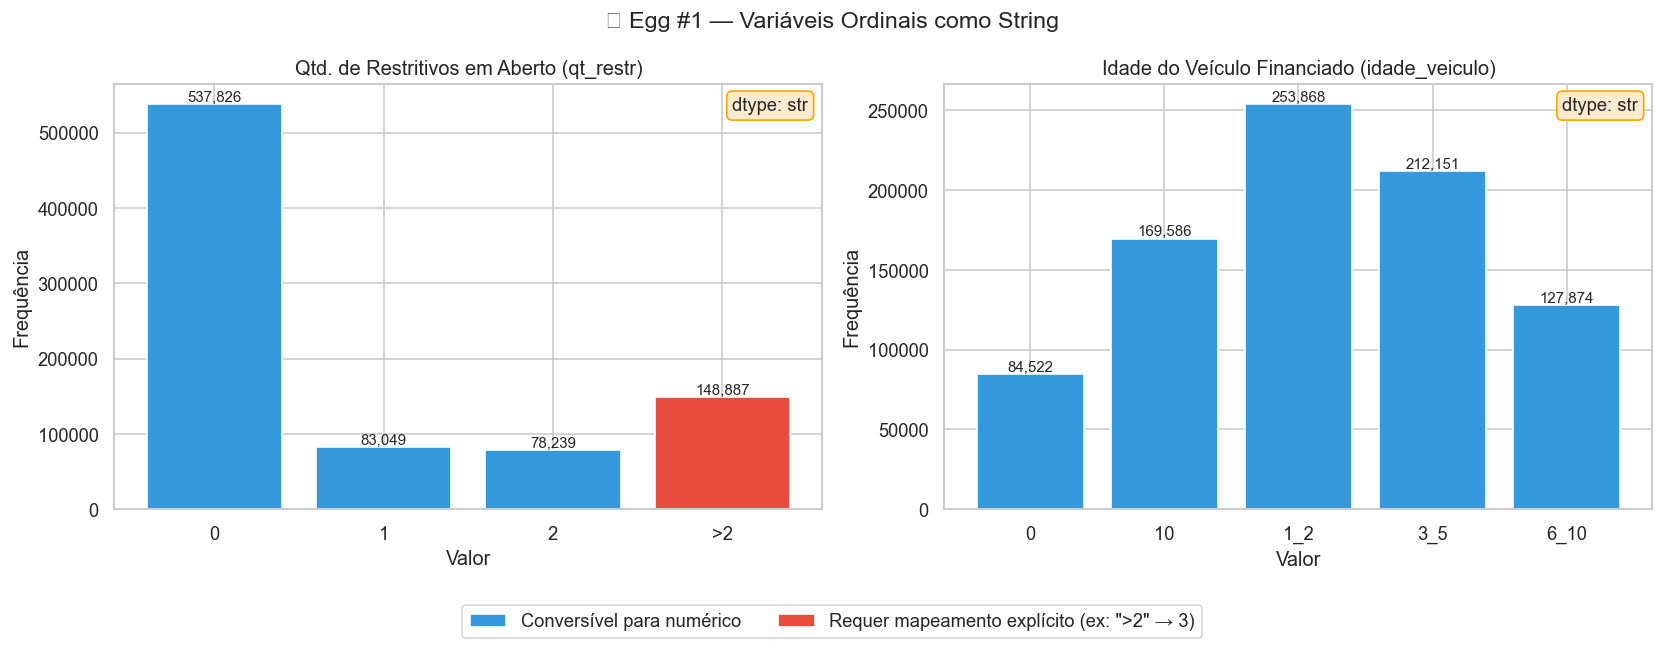

In [12]:
# Evidência: distribuição de valores — cores diferenciam valores problemáticos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, descricao) in zip(axes, [
    ('qt_restr',      'Qtd. de Restritivos em Aberto (qt_restr)'),
    ('idade_veiculo', 'Idade do Veículo Financiado (idade_veiculo)')
]):
    contagem = df[col].value_counts().sort_index()
    precisa_tratamento = [v for v in contagem.index
                          if not str(v).replace('_','').replace('+','').isdigit()]
    cores = ['#E74C3C' if str(v) in [str(p) for p in precisa_tratamento]
             else '#3498DB' for v in contagem.index]

    barras = ax.bar(contagem.index.astype(str), contagem.values, color=cores, edgecolor='white')

    # Anotar dtype
    ax.text(0.98, 0.97, f'dtype: {df[col].dtype}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='#FDEBD0', edgecolor='orange'))

    # Anotar contagens
    for barra, val in zip(barras, contagem.values):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

    ax.set_title(descricao, fontsize=12)
    ax.set_xlabel('Valor'); ax.set_ylabel('Frequência')

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#3498DB', label='Conversível para numérico'),
    Patch(facecolor='#E74C3C', label='Requer mapeamento explícito (ex: ">2" → 3)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=11)
plt.suptitle('🥚 Egg #1 — Variáveis Ordinais como String', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


### 🥚 Easter Egg #2 — Dado Inválido: `vl_bem = '25a70'`

Ao inspecionar os valores únicos das variáveis categóricas, encontramos em `vl_bem`
uma categoria que não existe no gabarito: `'25a70'`.

As categorias esperadas seguem o padrão `'XXaYY'` (ex: `'25a35'`, `'35a70'`) —
o valor `'25a70'` é tipicamente um erro de digitação ou de sistema.

**Impacto:** 1 registro com categoria fantasma. Em modelos categóricos, essa categoria
recebe um coeficiente próprio treinado com 1 observação — estatisticamente inútil
e potencialmente ruidoso.


**Ação recomendada:**
- Remover o registro antes de treinar ou avaliar o modelo
- Investigar a origem do valor `'25a70'` no sistema de entrada para evitar recorrência

In [13]:
# Evidencia: categorias de vl_bem
cats = sorted(df['vl_bem'].unique())
cats_df = pd.DataFrame({
    'categoria': cats,
    'obs'      : ['<-- INVALIDA (egg #2)' if c == '25a70' else '' for c in cats]
}).set_index('categoria')
display(cats_df)

# Registro com categoria invalida
display(df[df['vl_bem'] == '25a70'][['id', 'ano_mes', 'vl_bem', 'marca', 'score', 'contratado', 'target']])


,obs
categoria,
"(0, 25000]",
"(25000, 70000]",
"(70000, 999999]",
25a70,<-- INVALIDA (egg #2)


,id,ano_mes,vl_bem,marca,score,contratado,target
399824,362933522,2022-11-01,25a70,Outros,5,1,1.0


### 🥚 Easter Egg #3 — Chave Duplicada: 347 IDs com Múltiplas Ocorrências

Ao verificar a unicidade da chave `id`, encontramos 347 IDs que aparecem
**exatamente 2 vezes** com dados claramente distintos (datas, scores, resultados diferentes).

**Não são erros de carregamento** — são propostas legítimas feitas pelo mesmo
identificador em períodos diferentes.

**Impacto:**
- Contagens por cliente ficam infladas
- Joins com outras bases (cadastral, bureau) retornam duplicatas
- Modelos treinados com `id` como feature podem vazar informação entre propostas


**Ação recomendada:**
- Deduplicar usando `df.drop_duplicates(subset=['id', 'ano_mes'])` antes de agregar
- Não usar `id` como feature de modelo sem tratamento prévio

In [14]:
# Evidência: IDs com múltiplas ocorrências
id_counts  = df['id'].value_counts()
duplicados = id_counts[id_counts > 1]

display(pd.DataFrame({
    'Metrica': ['IDs unicos na base', 'IDs com 2+ ocorrencias', 'Registros afetados'],
    'Valor'  : [f'{df["id"].nunique():,}', f'{len(duplicados):,}', f'{duplicados.sum():,}']
}).set_index('Metrica'))

dist = id_counts.value_counts().rename_axis('vezes_na_base').reset_index(name='qtd_ids')
display(dist)
print()

# Exemplo real de ID duplicado
exemplo_id = duplicados.index[0]
print(f"Exemplo (id = {exemplo_id}):")
df[df['id'] == exemplo_id][['id', 'ano_mes', 'marca', 'vl_bem', 'score', 'contratado', 'target']]


,Valor
Metrica,
IDs unicos na base,"847,654"
IDs com 2+ ocorrencias,347
Registros afetados,694


,vezes_na_base,qtd_ids
0,1,847307
1,2,347



Exemplo (id = 683007563):


,id,ano_mes,marca,vl_bem,score,contratado,target
442,683007563,2023-01-01,Chevrolet,"(0, 25000]",7,1,0.0
588908,683007563,2022-12-01,Jac,"(25000, 70000]",5,1,0.0


## 1.2. Dimensão Temporal — Volume, Aprovação e Inadimplência

Com a base íntegra entendida, o próximo passo é olhar o **comportamento ao longo do tempo**:
a série temporal revela se houve mudanças de política, anomalias operacionais
ou limitações na janela de observação.


C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\3561312212.py:83: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


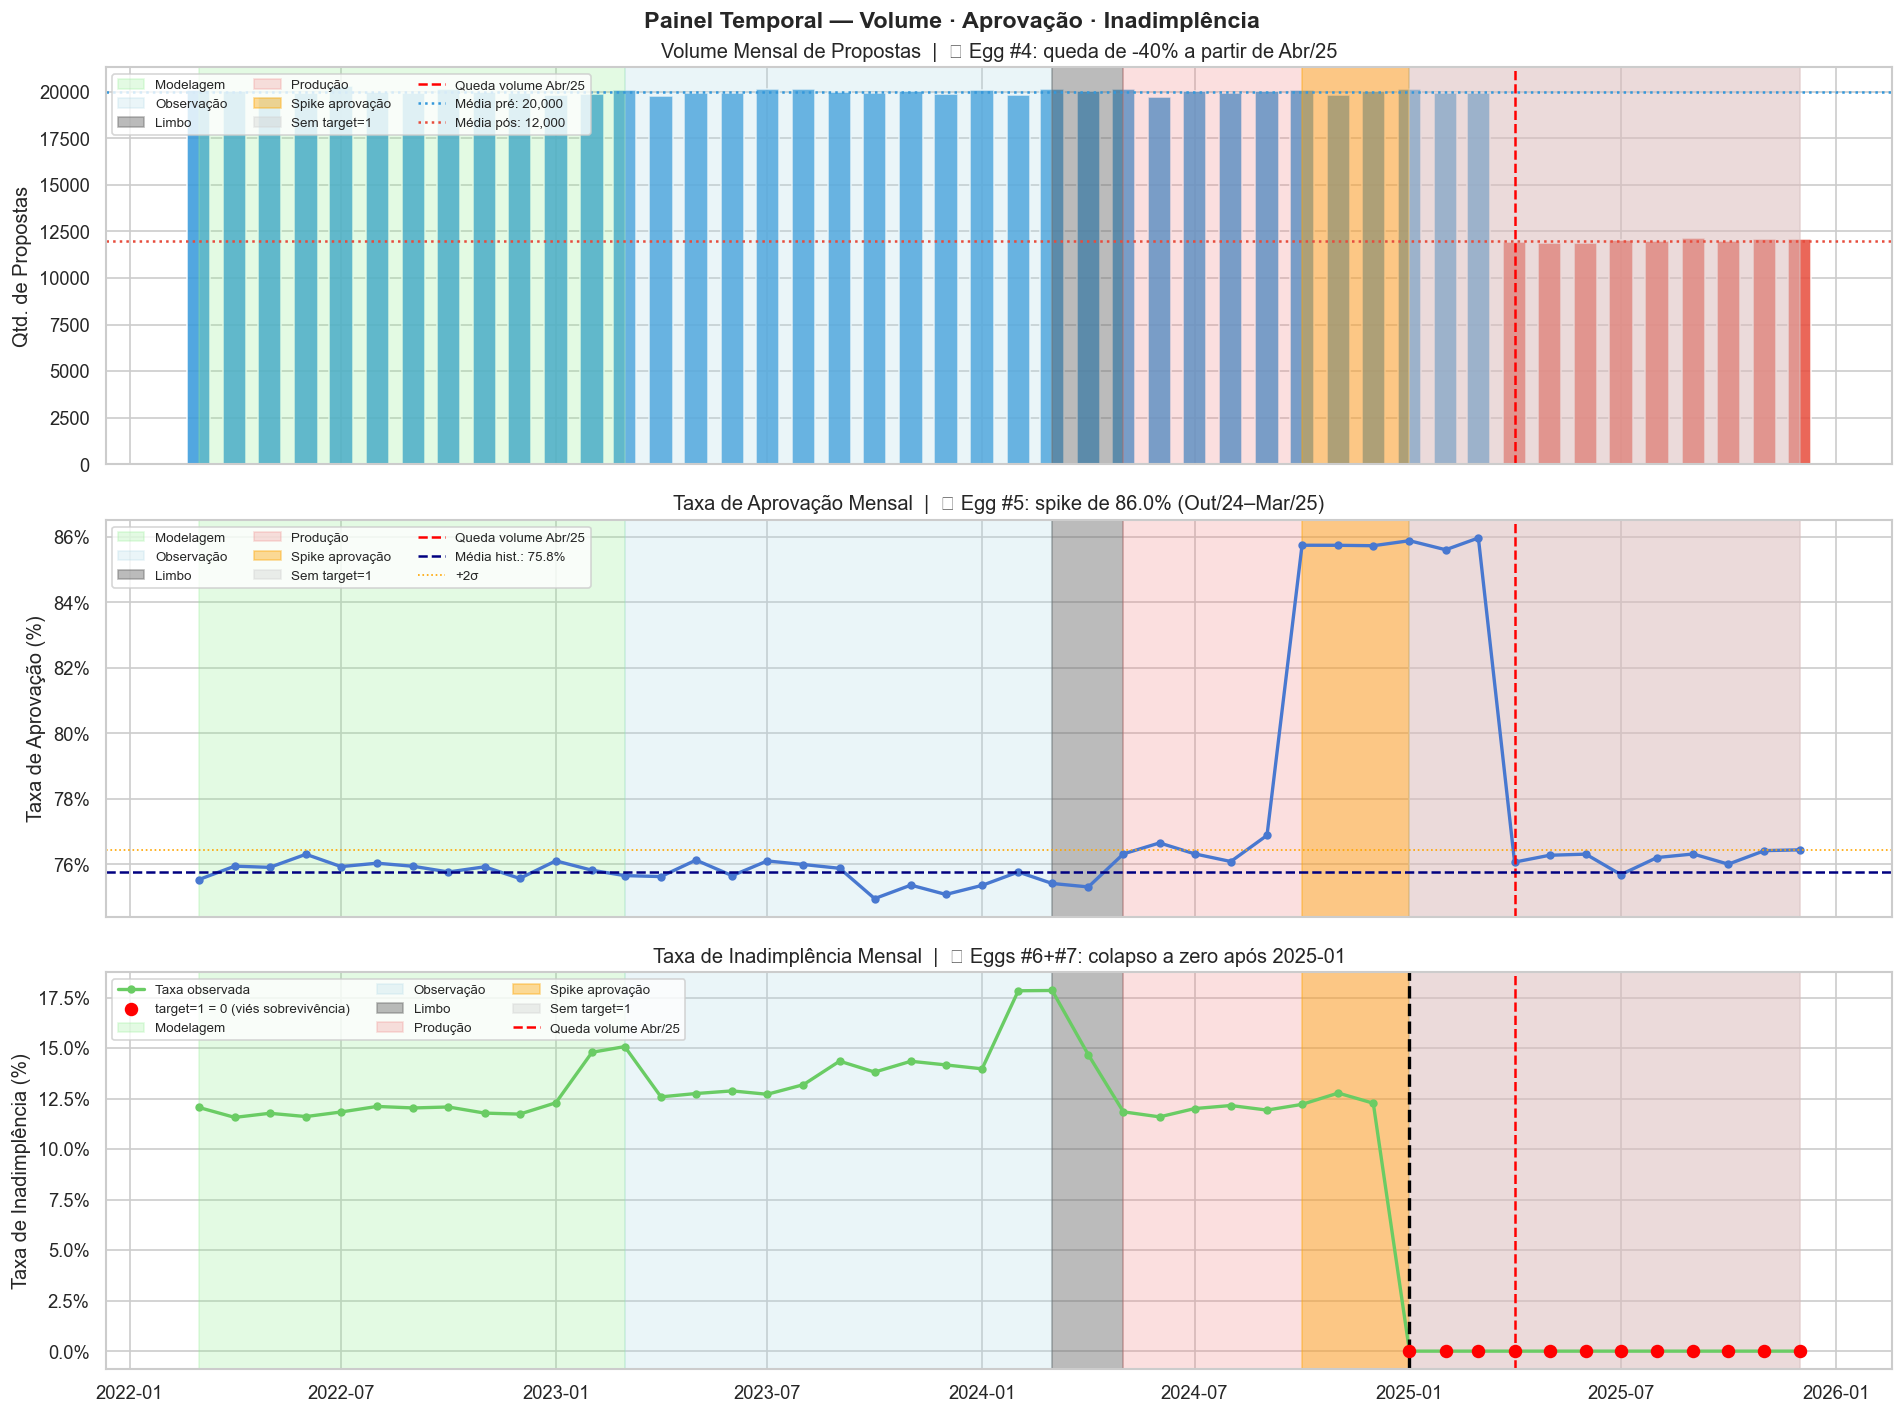

In [15]:
# Painel temporal: 3 métricas essenciais de uma vez
tabela_tempo = (df.groupby('ano_mes')
                  .agg(volume        =('id',         'count'),
                       taxa_aprovacao=('contratado', 'mean'),
                       qtd_inad      =('target',     lambda s: (s==1).sum()),
                       qtd_target    =('target',     lambda s: s.notna().sum()))
                  .reset_index())
tabela_tempo['taxa_inad'] = tabela_tempo.apply(
    lambda r: r['qtd_inad']/r['qtd_target'] if r['qtd_target'] > 0 else None, axis=1)

dt_mod_ini = pd.Timestamp(DT_MODELAGEM_INICIO)
dt_obs_ini = pd.Timestamp(DT_OBSERVACAO_INICIO)
dt_lim_ini = pd.Timestamp(DT_LIMBO_INICIO)
dt_pro_ini = pd.Timestamp(DT_PRODUCAO_INICIO)
dt_vaz_ini = pd.Timestamp(DT_VAZIO_INICIO)
dt_spk_ini = pd.Timestamp('2024-10-01')
dt_quebra  = pd.Timestamp('2025-04-01')

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Paleta de bandas (aplicada em todos os subplots)
def pintar_janelas(ax):
    tmax = tabela_tempo['ano_mes'].max()
    ax.axvspan(dt_mod_ini, dt_obs_ini, color=COR_MODELAGEM,  alpha=0.25, label='Modelagem')
    ax.axvspan(dt_obs_ini, dt_lim_ini, color=COR_OBSERVACAO, alpha=0.25, label='Observação')
    ax.axvspan(dt_lim_ini, dt_pro_ini, color=COR_LIMBO,      alpha=0.45, label='Limbo')
    ax.axvspan(dt_pro_ini, tmax,       color=COR_PRODUCAO,   alpha=0.25, label='Produção')
    ax.axvspan(dt_spk_ini, dt_vaz_ini, color=COR_SPIKE,      alpha=0.40, label='Spike aprovação')
    ax.axvspan(dt_vaz_ini, tmax,       color=COR_VAZIO,      alpha=0.40, label='Sem target=1')
    ax.axvline(dt_quebra,  color='red', lw=1.5, linestyle='--', label='Queda volume Abr/25')

# ── Painel 1: Volume ──────────────────────────────────────────────
ax0 = axes[0]
cores_vol = ['#3498DB' if r < dt_quebra else '#E74C3C'
             for r in tabela_tempo['ano_mes']]
ax0.bar(tabela_tempo['ano_mes'], tabela_tempo['volume'], color=cores_vol, width=20, alpha=0.85)
pintar_janelas(ax0)
media_pre_quebra = tabela_tempo.loc[tabela_tempo['ano_mes'] < dt_quebra, 'volume'].mean()
media_pos_quebra = tabela_tempo.loc[tabela_tempo['ano_mes'] >= dt_quebra, 'volume'].mean()
ax0.axhline(media_pre_quebra, color='#3498DB', lw=1.5, linestyle=':', label=f'Média pré: {media_pre_quebra:,.0f}')
ax0.axhline(media_pos_quebra, color='#E74C3C', lw=1.5, linestyle=':', label=f'Média pós: {media_pos_quebra:,.0f}')
delta_vol = (media_pos_quebra - media_pre_quebra) / media_pre_quebra * 100
ax0.set_title(f'Volume Mensal de Propostas  |  🥚 Egg #4: queda de {delta_vol:.0f}% a partir de Abr/25', fontsize=12)
ax0.set_ylabel('Qtd. de Propostas')
ax0.legend(loc='upper left', fontsize=8, ncol=3)

# ── Painel 2: Taxa de Aprovação ───────────────────────────────────
ax1 = axes[1]
ax1.plot(tabela_tempo['ano_mes'], tabela_tempo['taxa_aprovacao']*100,
         'b-o', lw=2, markersize=4)
pintar_janelas(ax1)
mask_ref = tabela_tempo['ano_mes'] < dt_lim_ini
media_hist = tabela_tempo.loc[mask_ref, 'taxa_aprovacao'].mean()
std_hist   = tabela_tempo.loc[mask_ref, 'taxa_aprovacao'].std()
ax1.axhline(media_hist*100,          color='navy', lw=1.5, linestyle='--', label=f'Média hist.: {media_hist*100:.1f}%')
ax1.axhline((media_hist+2*std_hist)*100, color='orange', lw=1, linestyle=':', label='+2σ')
pico_aprov = tabela_tempo['taxa_aprovacao'].max()*100
ax1.set_title(f'Taxa de Aprovação Mensal  |  🥚 Egg #5: spike de {pico_aprov:.1f}% (Out/24–Mar/25)', fontsize=12)
ax1.set_ylabel('Taxa de Aprovação (%)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0f}%'))
ax1.legend(loc='upper left', fontsize=8, ncol=3)

# ── Painel 3: Taxa de Inadimplência ──────────────────────────────
ax2 = axes[2]
mask_inad = tabela_tempo['taxa_inad'].notna()
ax2.plot(tabela_tempo.loc[mask_inad, 'ano_mes'],
         tabela_tempo.loc[mask_inad, 'taxa_inad']*100,
         'g-o', lw=2, markersize=4, label='Taxa observada')
# Zero após Jan/25
mask_zero = tabela_tempo['taxa_inad'] == 0
if mask_zero.any():
    ax2.scatter(tabela_tempo.loc[mask_zero, 'ano_mes'],
                tabela_tempo.loc[mask_zero, 'taxa_inad'],
                color='red', s=50, zorder=5, label='target=1 = 0 (viés sobrevivência)')
pintar_janelas(ax2)
ax2.axvline(dt_vaz_ini, color='black', lw=2, linestyle='--')
ax2.set_title(f'Taxa de Inadimplência Mensal  |  🥚 Eggs #6+#7: colapso a zero após {DT_VAZIO_INICIO[:7]}', fontsize=12)
ax2.set_ylabel('Taxa de Inadimplência (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1f}%'))
ax2.legend(loc='upper left', fontsize=8, ncol=3)

plt.suptitle('Painel Temporal — Volume · Aprovação · Inadimplência', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> **Leitura do painel acima — três achados de uma vez:**
>
> - **🥚 Egg #4** (barra vermelha): queda abrupta e permanente de ~40% no volume a partir de Abr/25.
>   A taxa de aprovação se mantém → a queda é no **topo do funil** (menos propostas chegando), não em mais rejeições.
>
> - **🥚 Egg #5** (banda laranja): a taxa de aprovação sobe ~10 p.p. entre Out/24 e Mar/25,
>   coincidindo com o "Efeito Modelo Produção". Perfil de risco atípico nesse período.
>
> - **🥚 Eggs #6 e #7** (banda cinza): a taxa de inadimplência cai a **zero** a partir de Jan/25.
>   Não é que o modelo melhorou — contratos de Jan/25 ainda não tiveram 12 meses para madurar.
>   Usar esse período em modelos de inadimplência produz **viés de sobrevivência**.


**Ações recomendadas:**
- **Egg #4**: tratar Abr/25+ como sub-período separado; ampliar IC das cartas de controle
- **Egg #5**: excluir Out/24–Mar/25 das análises de discriminação como sub-período atípico
- **Eggs #6+#7**: não usar `ano_mes >= Jan/25` como janela de avaliação de inadimplência;
  aguardar maturação completa (12 meses) antes de qualquer conclusão sobre esse período

### 🥚 Easter Egg #8 — Período de Limbo: Transição entre Modelos (Mar/24–Abr/24)

O período de **Mar/24 a Abr/24** é uma transição entre o modelo de observação e o modelo
em produção. O comportamento é híbrido: parte das propostas foram avaliadas pelo modelo antigo,
parte pelo novo.

**Evidência:** o score médio e a taxa de aprovação apresentam descontinuidade nesses dois meses,
que não se explica por sazonalidade nem por mudança de perfil da carteira.

**Impacto:** incluir o limbo em análises de série temporal sem um flag explícito
cria uma quebra estrutural artificial — o monitoramento vai "ver" instabilidade
onde há apenas troca de modelo.


**Ação recomendada:**
- Excluir o período de limbo (Mar–Abr/24) do cálculo das janelas de referência do PSI
- Manter a coluna `janela = 'limbo'` como flag; nunca usar como janela de modelagem

C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\4127383338.py:37: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  plt.tight_layout()


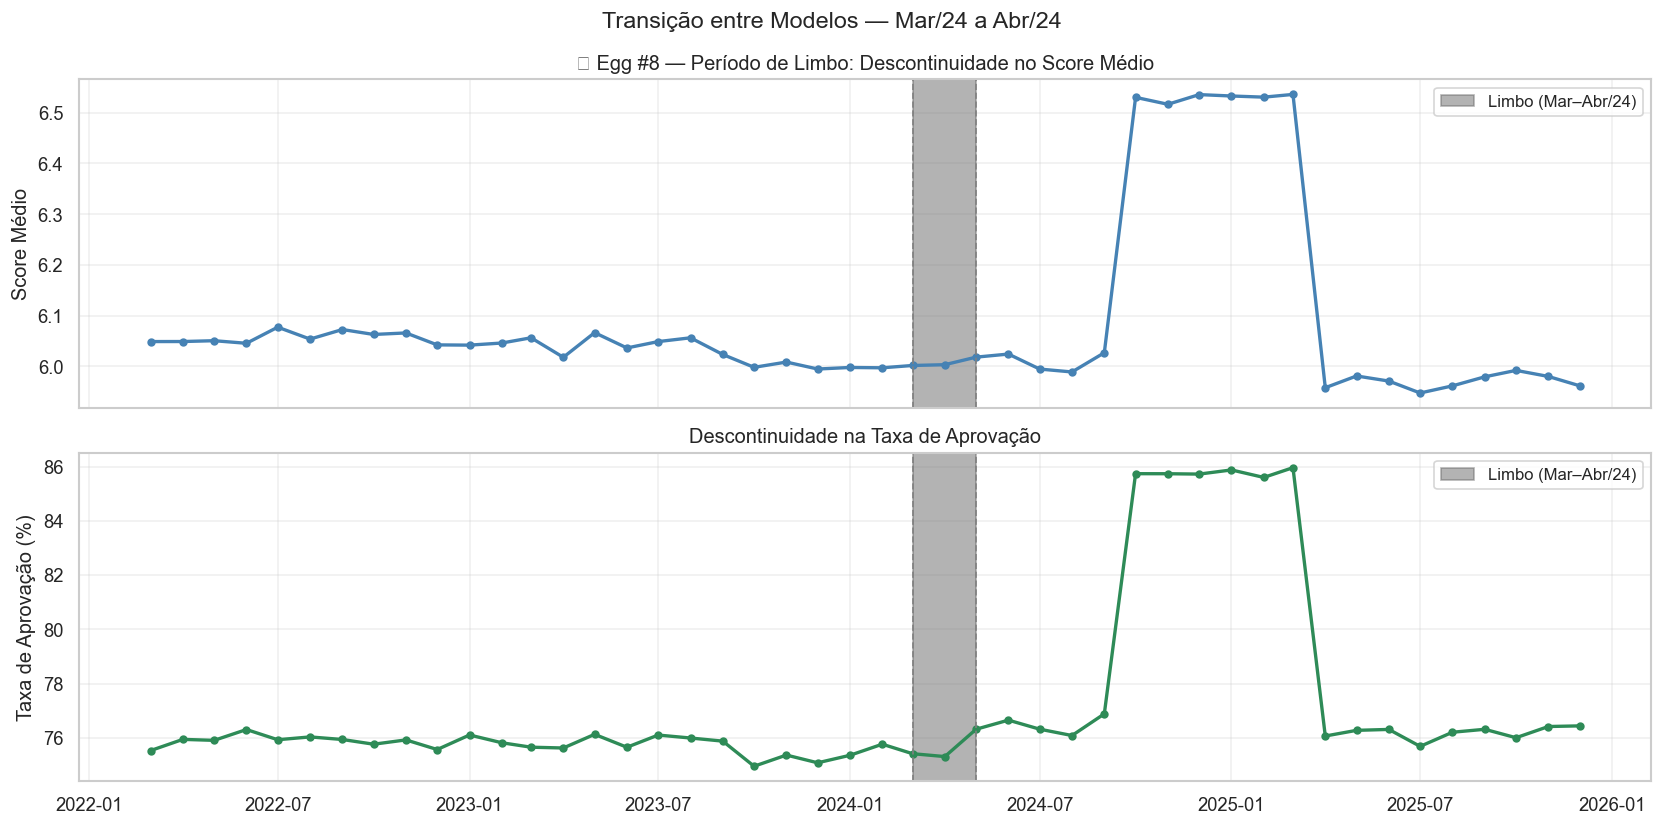

In [16]:
# Evidência: score médio e taxa de aprovação no período de limbo vs adjacentes
tabela_limbo = (df.groupby('ano_mes')
                  .agg(score_medio    =('score',      'mean'),
                       taxa_aprovacao =('contratado', 'mean'))
                  .reset_index())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, (col, rotulo, cor) in zip([ax1, ax2], [
    ('score_medio',    'Score Médio',          'steelblue'),
    ('taxa_aprovacao', 'Taxa de Aprovação (%)', 'seagreen')
]):
    vals = tabela_limbo[col] * (100 if col == 'taxa_aprovacao' else 1)
    ax.plot(tabela_limbo['ano_mes'], vals, '-o', color=cor, lw=2, markersize=4)
    ax.axvspan(pd.Timestamp(DT_LIMBO_INICIO), pd.Timestamp(DT_PRODUCAO_INICIO),
               color=COR_LIMBO, alpha=0.5, label='Limbo (Mar–Abr/24)')
    ax.axvline(pd.Timestamp(DT_LIMBO_INICIO),    color='gray', lw=1, linestyle='--')
    ax.axvline(pd.Timestamp(DT_PRODUCAO_INICIO), color='gray', lw=1, linestyle='--')
    ax.set_ylabel(rotulo)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Números de confirmação no plot
for per, inicio, fim, cor_txt in [
    ('Pré-limbo',    DT_OBSERVACAO_INICIO, DT_LIMBO_INICIO, '#3ECC71'),
    ('Limbo',        DT_LIMBO_INICIO,      DT_PRODUCAO_INICIO, 'gray'),
    ('Pós-limbo',   DT_PRODUCAO_INICIO,   DT_VAZIO_INICIO, '#E74C3C'),
]:
    mask = (tabela_limbo['ano_mes'] >= pd.Timestamp(inicio)) &            (tabela_limbo['ano_mes'] < pd.Timestamp(fim))
    if mask.any():
        m_score = tabela_limbo.loc[mask, 'score_medio'].mean()
        m_aprov = tabela_limbo.loc[mask, 'taxa_aprovacao'].mean()*100

ax1.set_title('🥚 Egg #8 — Período de Limbo: Descontinuidade no Score Médio', fontsize=12)
ax2.set_title('Descontinuidade na Taxa de Aprovação', fontsize=12)
plt.suptitle('Transição entre Modelos — Mar/24 a Abr/24', fontsize=14)
plt.tight_layout()
plt.show()


## 1.3. Perfil do Aprovado — Distribuição das Variáveis

Com o comportamento temporal mapeado, passamos para a distribuição das variáveis
por grupo (contratados, adimplentes, inadimplentes) e por janela temporal.

Objetivo: verificar se o **perfil de quem entra no modelo** mudou entre as janelas —
o que afeta diretamente a interpretação das métricas de monitoramento.


### 🥚 Easter Egg #9 — Política Descontinuada: Scores 1–4 em Produção

O modelo atual opera apenas com scores 5–10 (scores 1–4 foram descontinuados pela política de crédito).
No entanto, registros com scores 1–4 continuam presentes na base até a janela de produção.

**Impacto para o monitoramento:**
- Incluir scores 1–4 no PSI e na carta de controle cria **falsa impressão de instabilidade**:
  o PSI vai "ver" a ausência desses scores como deriva populacional, quando na verdade
  é apenas uma mudança de política.
- Por isso, o monitoramento **filtra score > 4** (constante `SCORE_MINIMO`).


**Ação recomendada:**
- Aplicar `filtro: score > SCORE_MINIMO` em **todas** as métricas de monitoramento
- Documentar a descontinuação na documentação do modelo para auditoria futura

Registros com score <= 4: 186,824  (22.0% da base total)



score,1,2,3,4,5,6,7,8,9,10
janela,,,,,,,,,,
limbo,1234,1699,2884,3763,5369,6344,8392,6251,3488,813
modelagem,7195,9525,16929,21352,31295,38184,50673,38082,21482,5172
observacao,7498,9741,16826,21854,31449,38171,51269,37441,20798,4893
producao,3627,5112,9914,13443,20594,25718,36002,27297,15008,3220
vazio,3842,5558,10365,14463,21854,27656,37611,28521,15091,3039


C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\3986310578.py:41: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


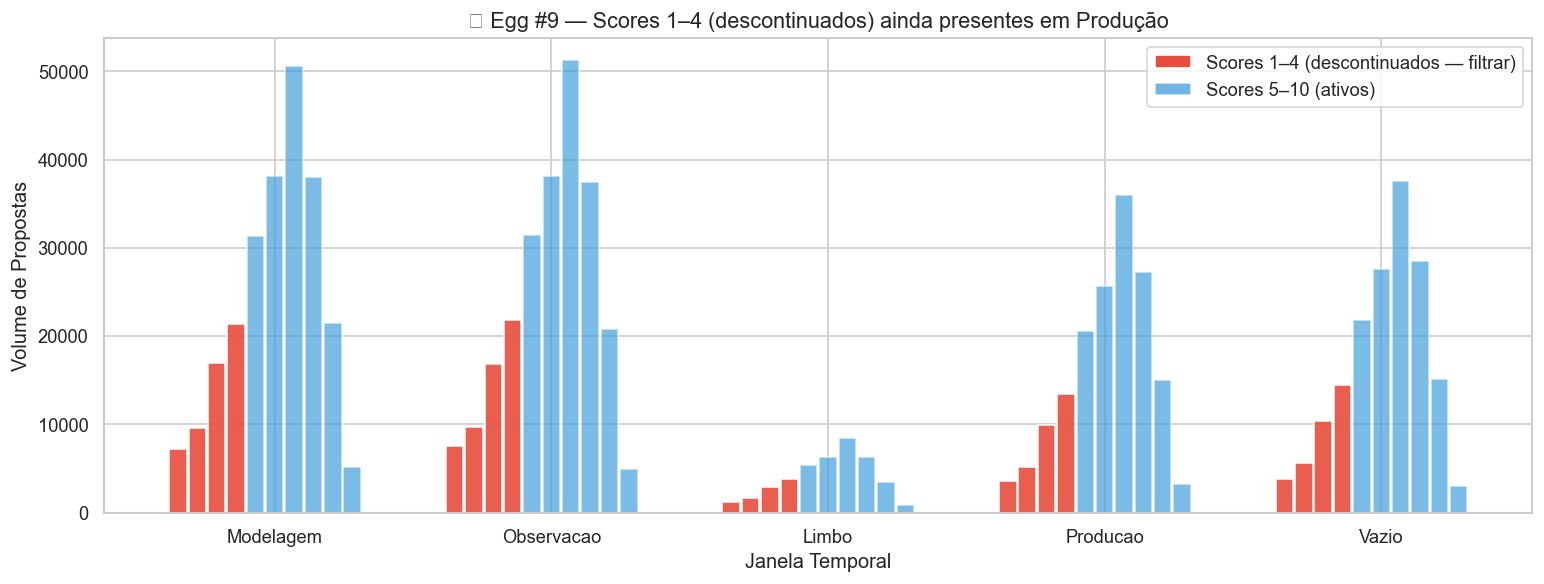

In [18]:
# Evidência: scores 1-4 presentes em produção
total        = len(df)
scores_desc  = df[df['score'] <= SCORE_MINIMO]
print(f"Registros com score <= {SCORE_MINIMO}: {len(scores_desc):,}  ({len(scores_desc)/total*100:.1f}% da base total)")
print()

# Tabela por janela
tabela_s = (df.groupby(['janela', 'score'])
              .size()
              .rename('volume')
              .reset_index()
              .pivot(index='janela', columns='score', values='volume')
              .fillna(0)
              .astype(int))
display(tabela_s)
# Grafico
ordem_janelas = ['modelagem', 'observacao', 'limbo', 'producao', 'vazio']
janelas_ok    = [j for j in ordem_janelas if j in df['janela'].unique()]
scores_todos  = sorted(df['score'].dropna().unique())
width         = 0.07
x             = range(len(janelas_ok))

fig, ax = plt.subplots(figsize=(13, 5))
for i, score in enumerate(scores_todos):
    cor   = '#E74C3C' if score <= SCORE_MINIMO else '#3498DB'
    alpha = 0.9 if score <= SCORE_MINIMO else 0.65
    vols  = [df[(df['janela']==j) & (df['score']==score)].shape[0] for j in janelas_ok]
    offset = (i - len(scores_todos)/2) * width
    ax.bar([xi + offset for xi in x], vols, width=width*0.9, color=cor, alpha=alpha)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#E74C3C', label=f'Scores 1–{SCORE_MINIMO} (descontinuados — filtrar)'),
    Patch(facecolor='#3498DB', alpha=0.7, label=f'Scores {SCORE_MINIMO+1}–10 (ativos)'),
], fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels([j.capitalize() for j in janelas_ok])
ax.set_title(f'🥚 Egg #9 — Scores 1–{SCORE_MINIMO} (descontinuados) ainda presentes em Produção', fontsize=13)
ax.set_xlabel('Janela Temporal')
ax.set_ylabel('Volume de Propostas')
plt.tight_layout()
plt.show()


### 1.3.1. Variáveis Categóricas por Janela

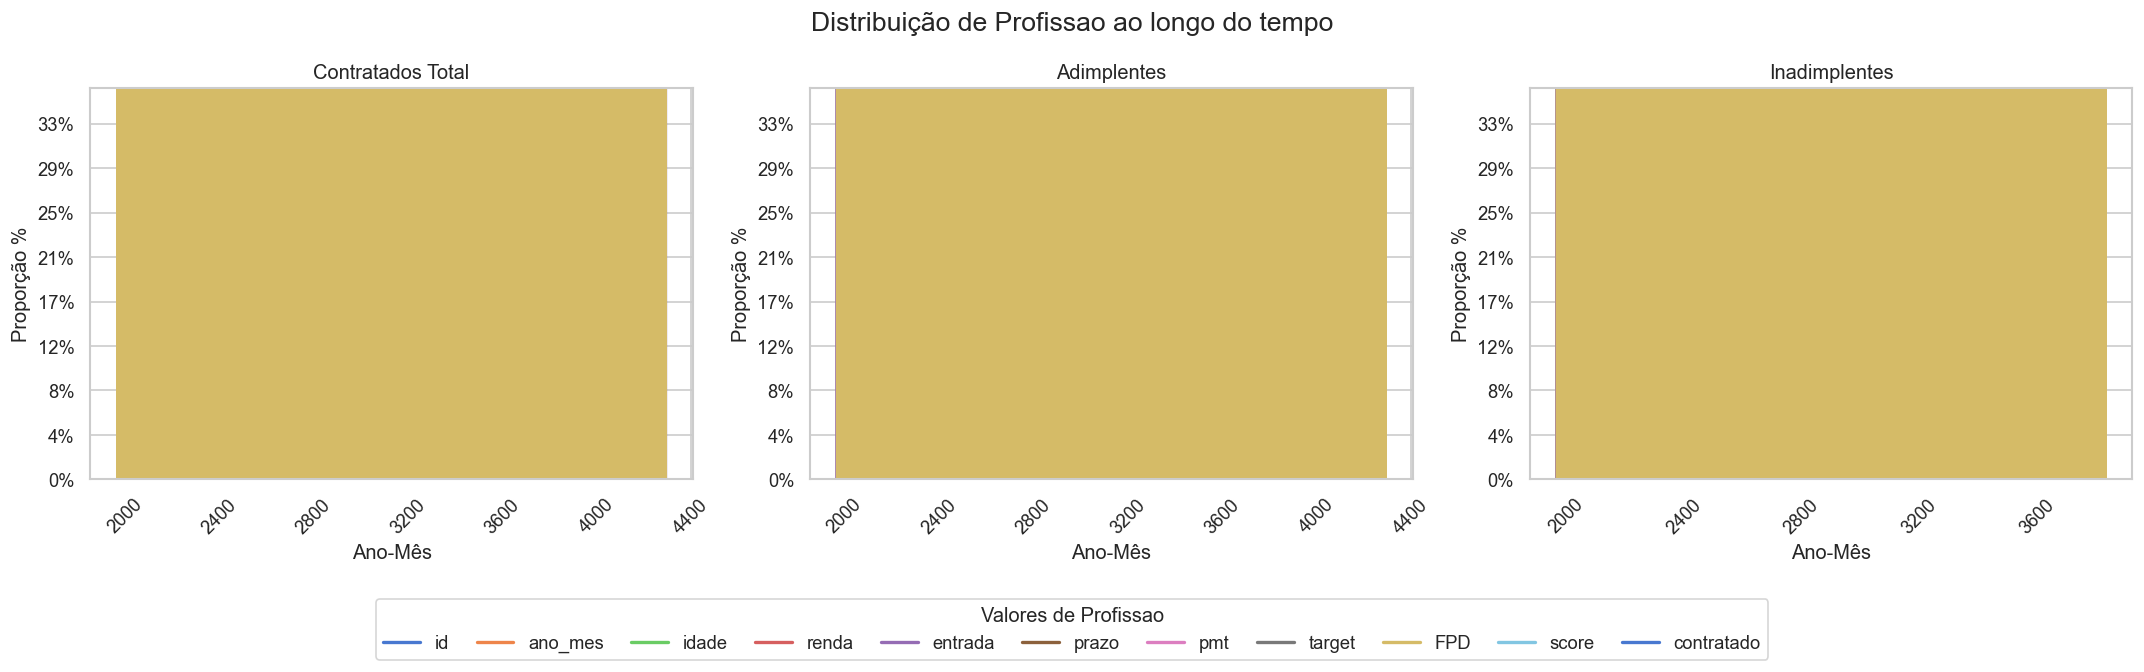

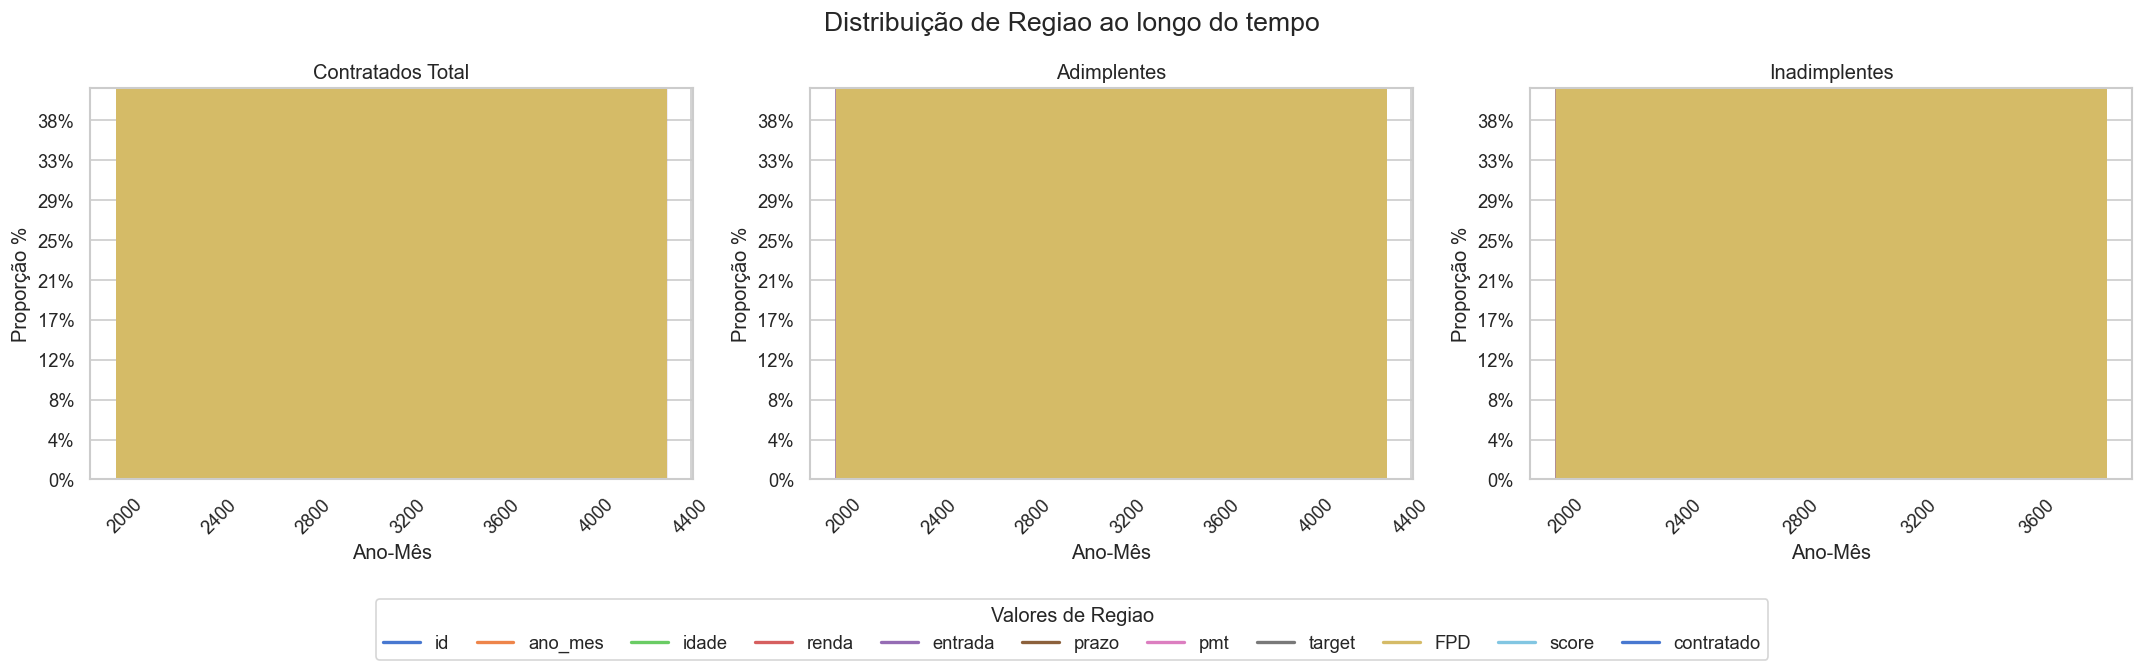

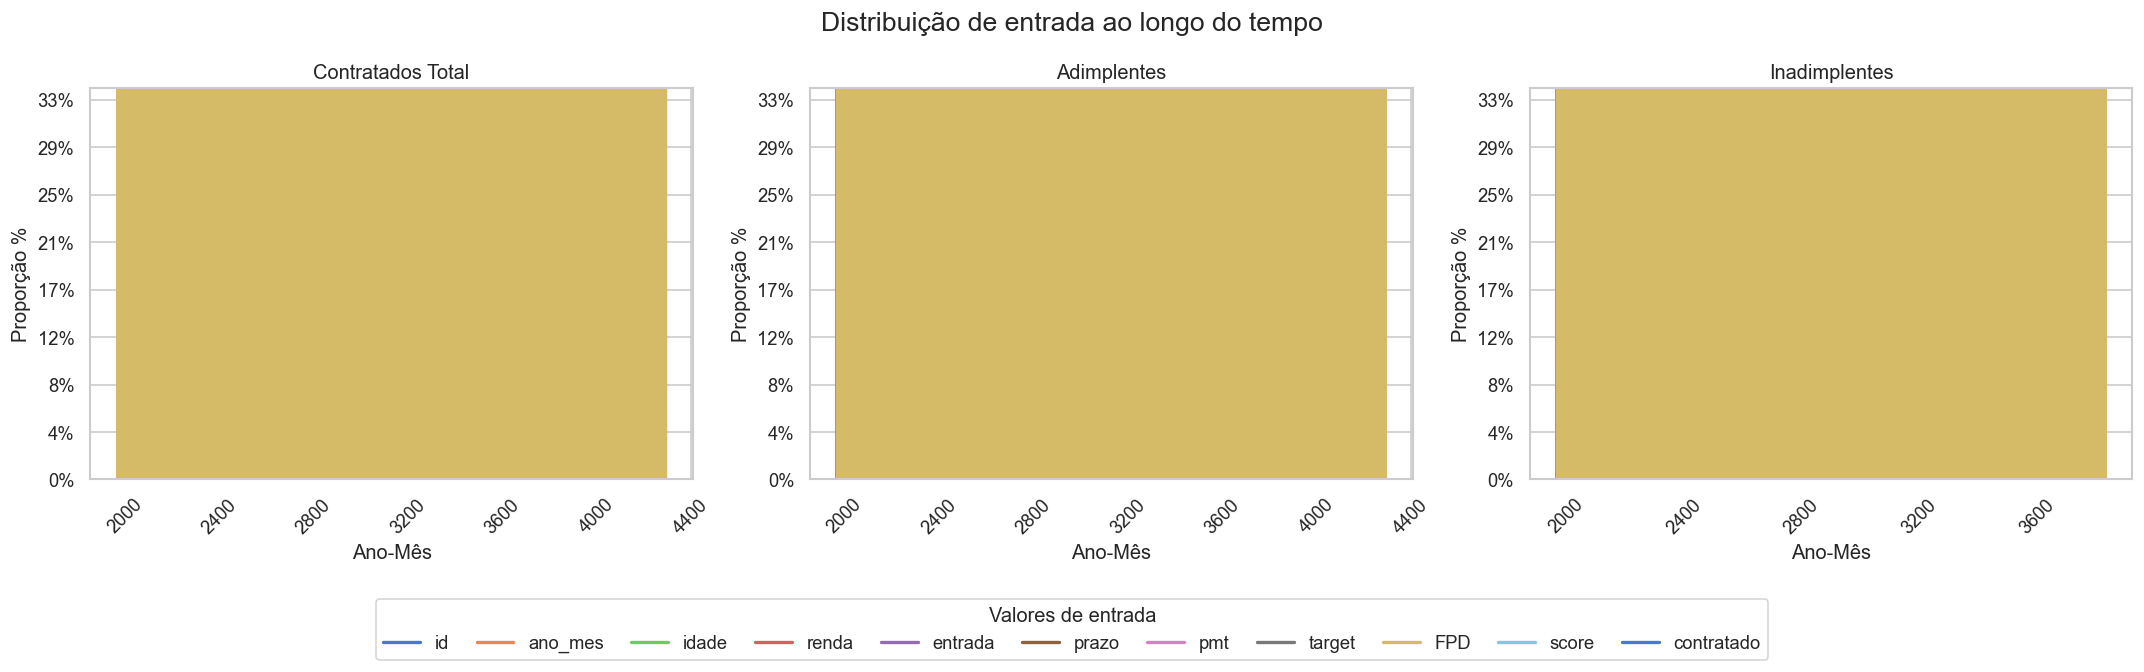

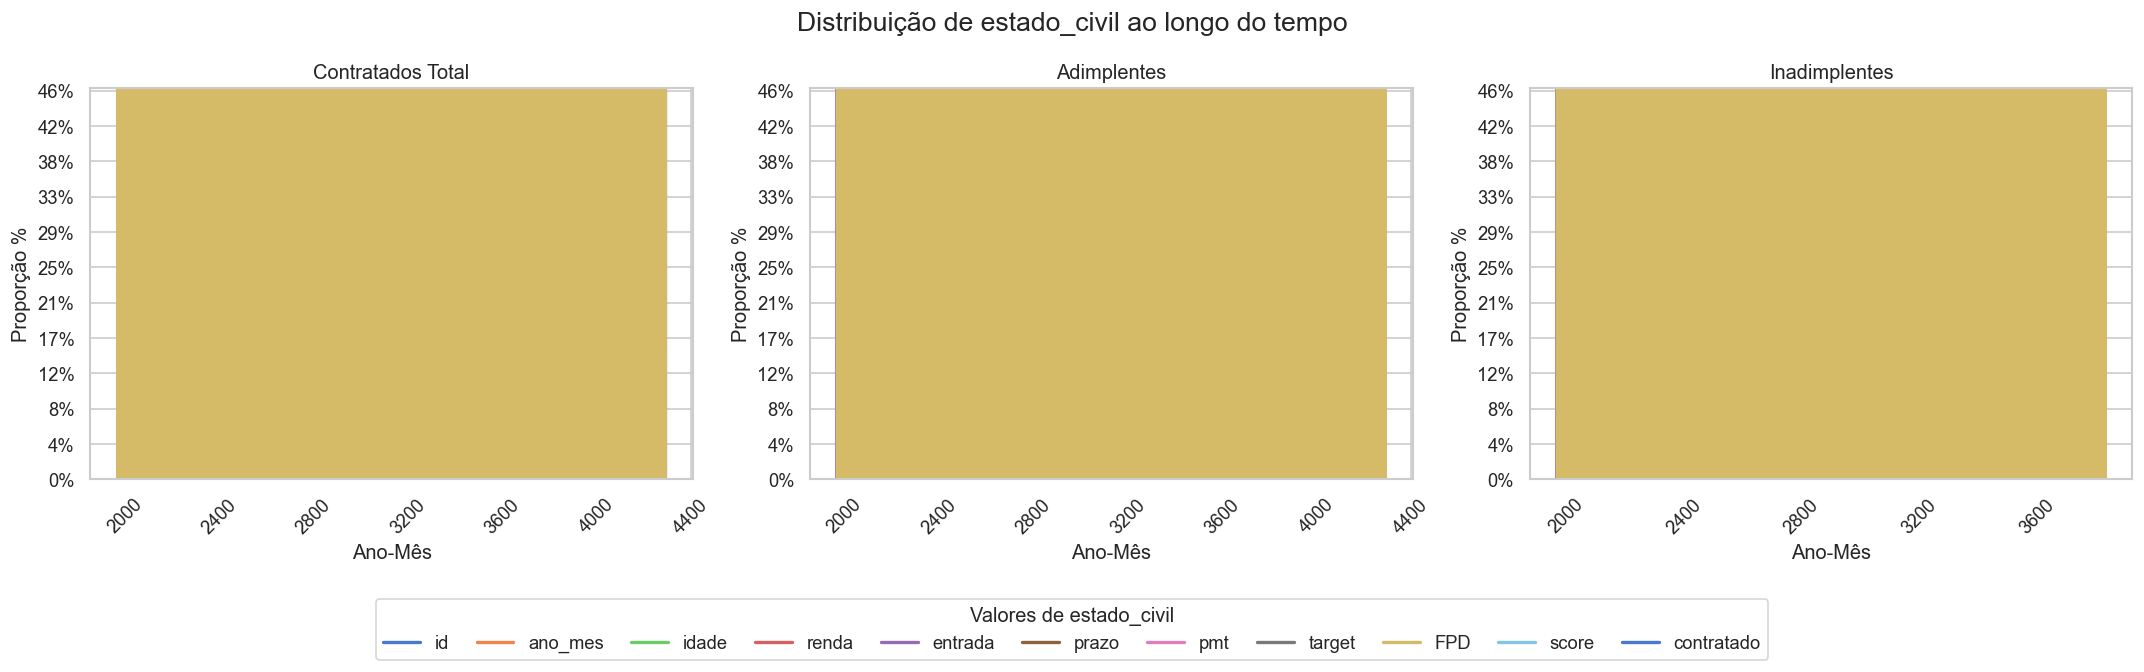

KeyboardInterrupt: 

In [19]:
# Distribuição das variáveis categóricas ao longo do tempo por grupo
cols_cat_plot = [c for c in cat_cols if c not in ['ano_mes', 'FPD', 'tipo', 'janela']]
for coluna in cols_cat_plot:
    plot_distribuicao_por_grupos(df_contratado, df_adimplente, df_inadimplente, coluna)


### 1.3.2. Variáveis Numéricas por Janela

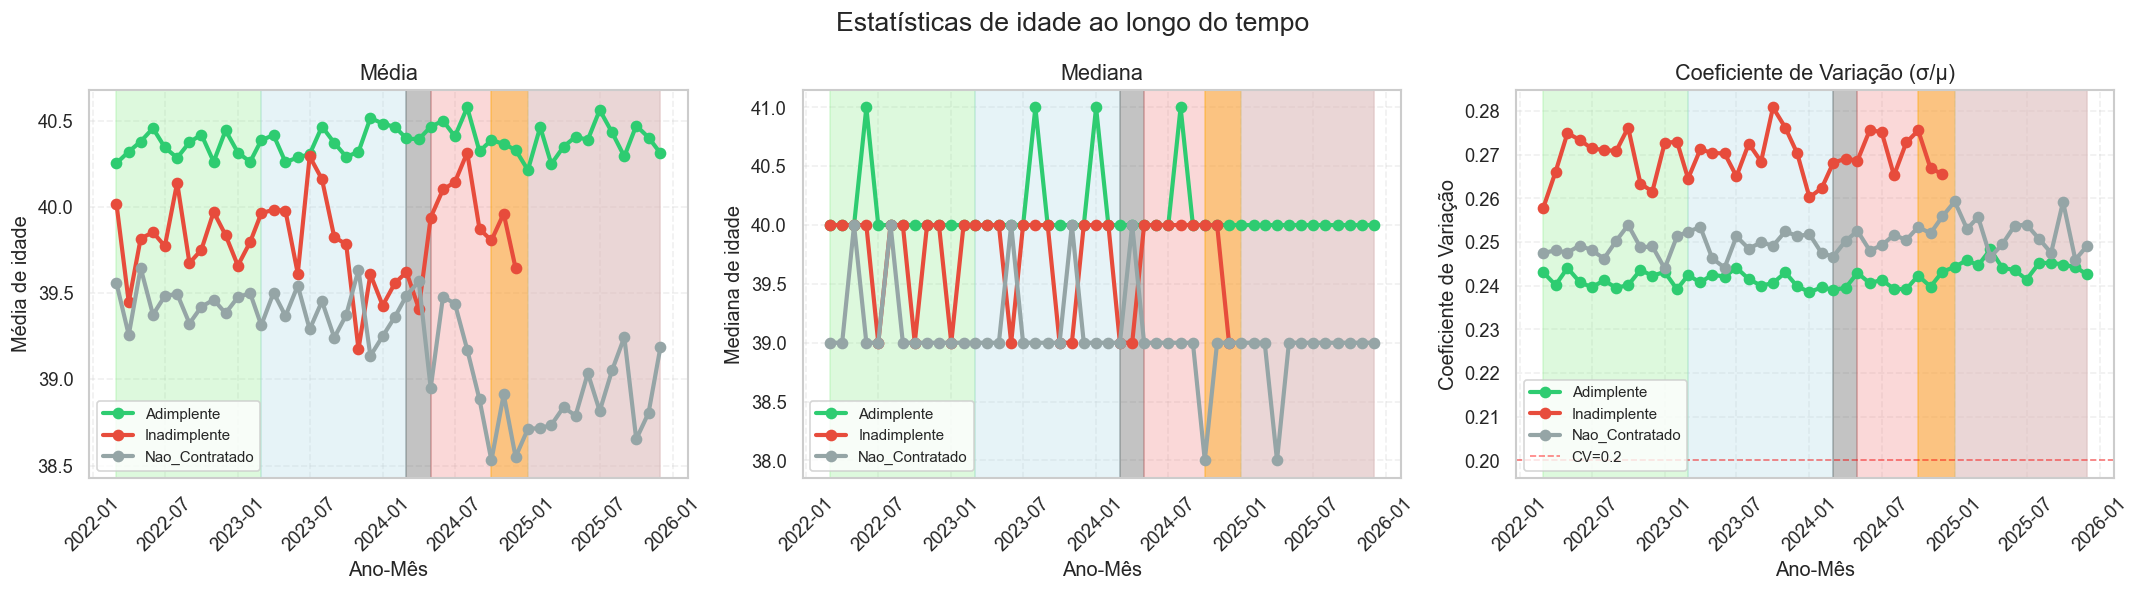

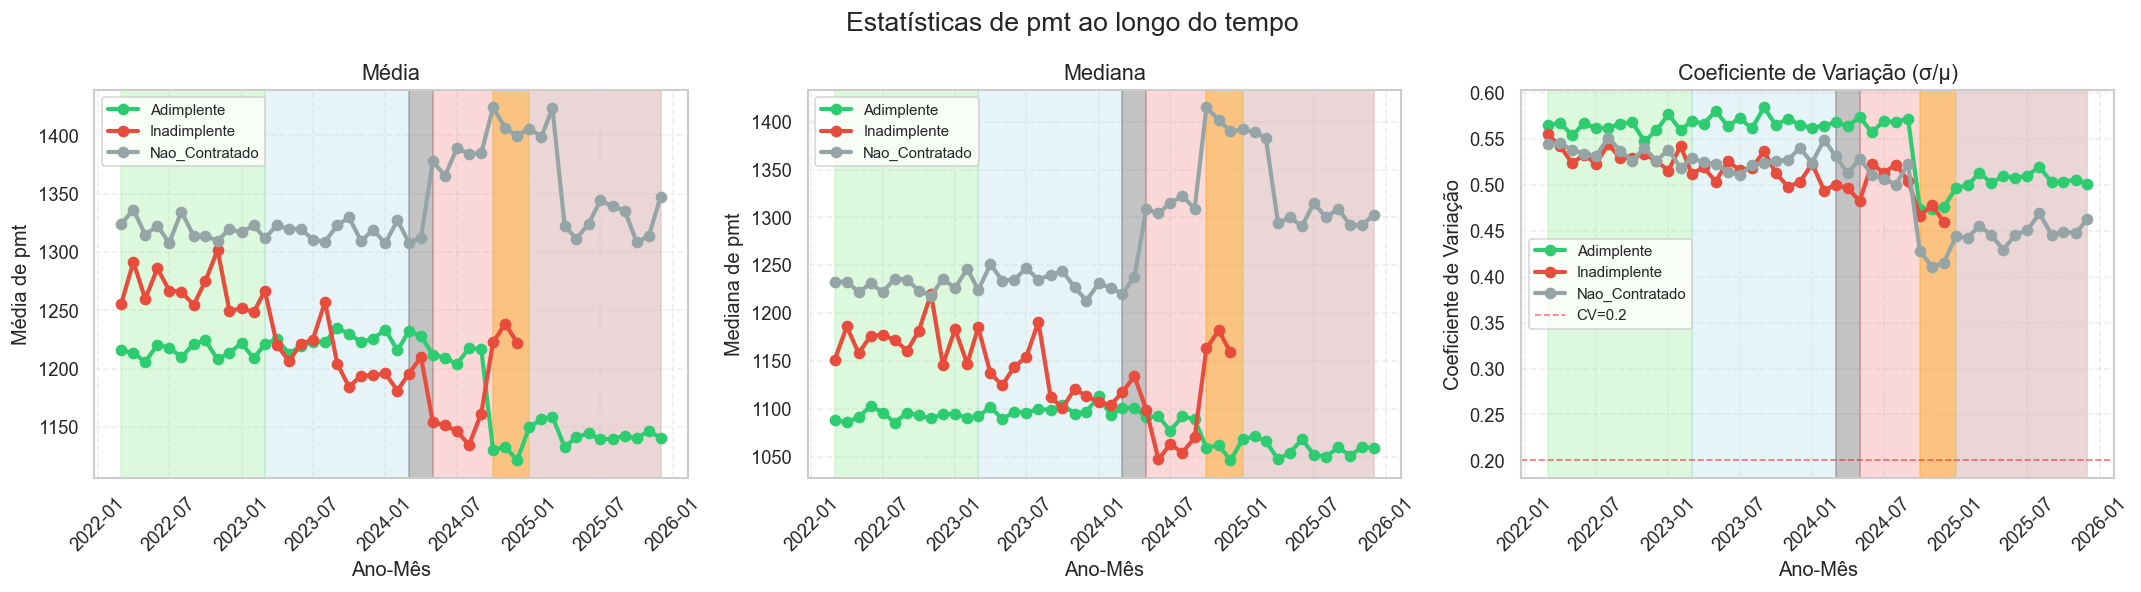

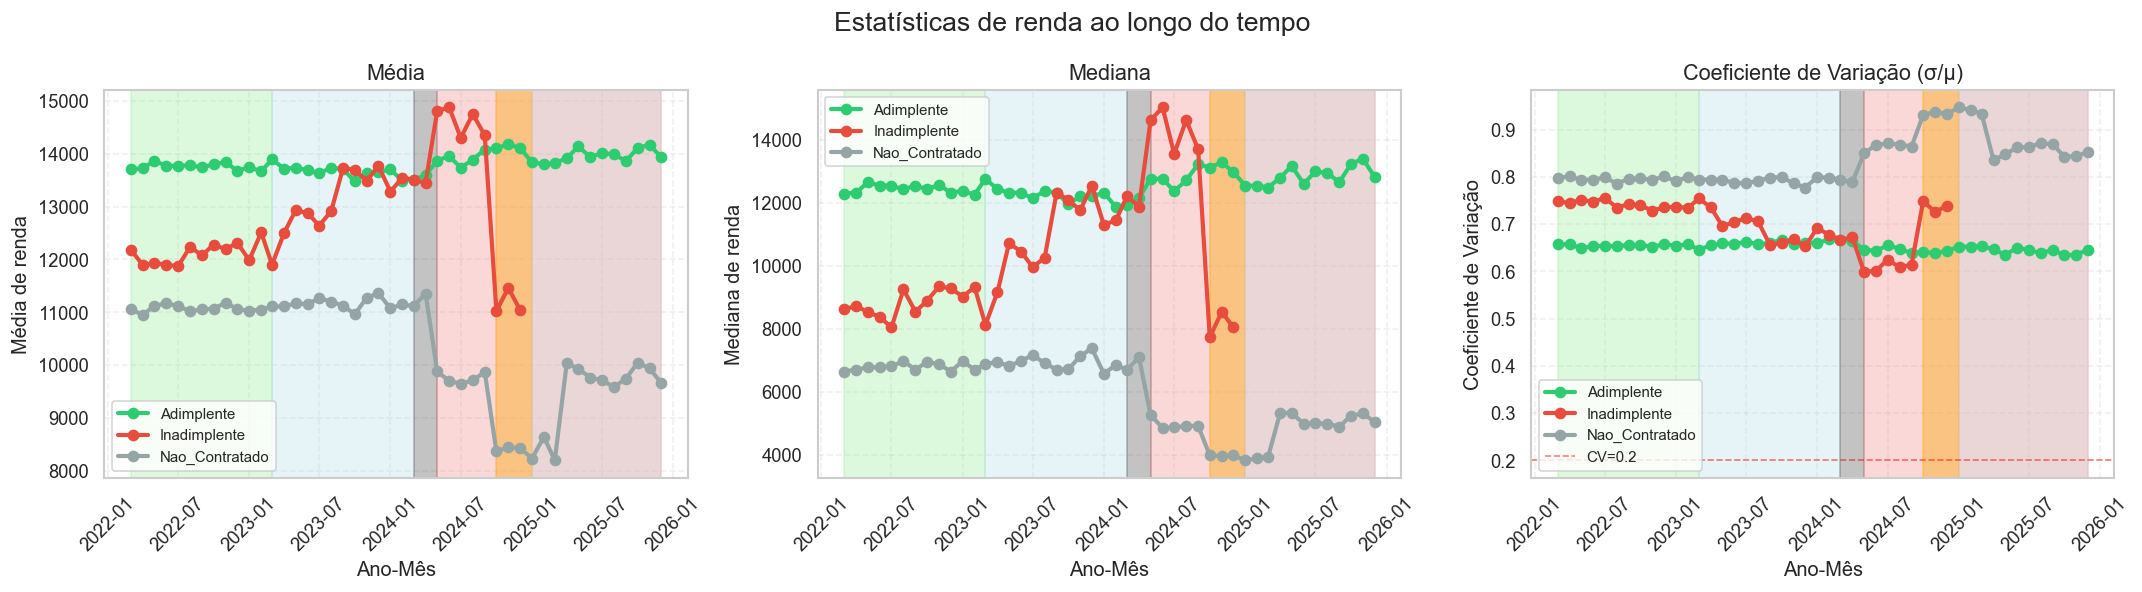

In [21]:
# Estatísticas das variáveis numéricas ao longo do tempo por tipo
for coluna in num_cols:
    plot_estatisticas_por_tipo(df, coluna)


## 1.4. Inadimplência — FPD e Perfil do Mau Pagador

Com o perfil geral mapeado, focamos agora em quem **inadimpliu**.
Perguntas-chave:

1. O FPD (inadimplência na 1ª parcela) é consistente com o target de 12 meses?
2. Qual é o perfil das variáveis para inadimplentes vs adimplentes?


### 🥚 Easter Egg #10 — Inconsistência Lógica: FPD=1 com target=0

`FPD=1` significa que o cliente **não pagou a 1ª parcela**.
Logicamente, quem não paga a 1ª parcela deveria ser inadimplente (`target=1`).

**O que encontramos:** **18.596 registros** onde `FPD=1` mas `target=0` —
isso representa **85,6%** de todos os casos de FPD=1.

**Hipóteses:**
- FPD e target são capturados por **sistemas diferentes com janelas distintas**:
  o FPD olha apenas o 1º mês, o target olha 12 meses completos
- O cliente deu FPD mas **regularizou** o pagamento antes de 12 meses → saiu como adimplente
- **Implicação direta:** FPD não é substituto do target em análises de inadimplência —
  as duas métricas medem coisas diferentes


**Ação recomendada:**
- Tratar FPD e target como métricas **complementares**, nunca substitutas
- Reportar FPD separadamente com janela de 1 mês; target com janela de 12 meses
- Investigar junto à área de sistemas se a janela de captura do FPD está documentada

FPD=1 com target=0: 18,596 registros  (85.6% dos FPD=1)



C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\204649550.py:42: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\204649550.py:42: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129370 (\N{EGG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


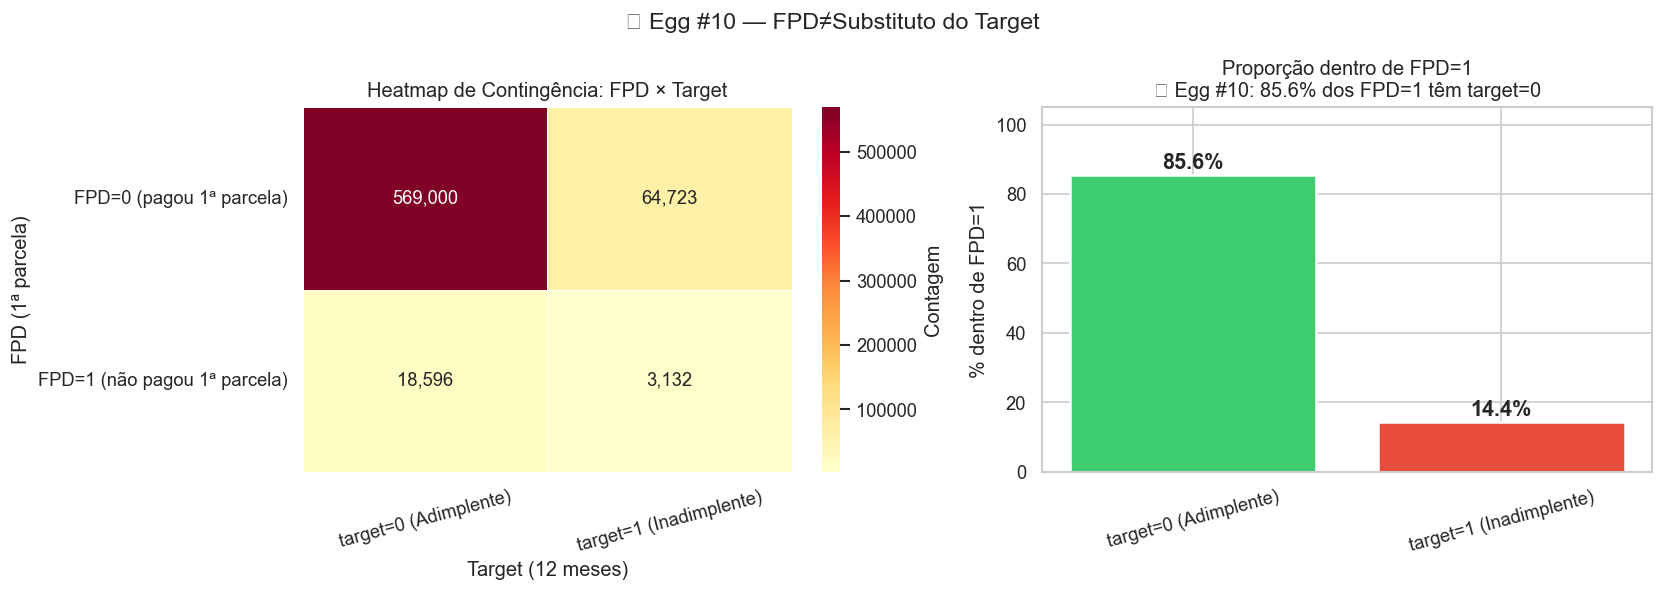

In [22]:
# Evidência: contingência FPD × target
df_cont  = df[df['contratado'] == 1].copy()
df_cont['fpd_int']    = df_cont['FPD'].fillna(-1).astype(int)
df_cont['target_int'] = df_cont['target'].fillna(-1).astype(int)
df_fpd_t = df_cont[(df_cont['fpd_int'] >= 0) & (df_cont['target_int'] >= 0)]

contingencia = pd.crosstab(df_fpd_t['fpd_int'], df_fpd_t['target_int'])
contingencia.index   = ['FPD=0 (pagou 1ª parcela)', 'FPD=1 (não pagou 1ª parcela)']
contingencia.columns = ['target=0 (Adimplente)',    'target=1 (Inadimplente)']

# Highlight do achado
total_fpd1     = contingencia.loc['FPD=1 (não pagou 1ª parcela)'].sum()
fpd1_target0   = contingencia.loc['FPD=1 (não pagou 1ª parcela)', 'target=0 (Adimplente)']
pct_inconsist  = fpd1_target0 / total_fpd1 * 100
print(f"FPD=1 com target=0: {fpd1_target0:,} registros  ({pct_inconsist:.1f}% dos FPD=1)")
print()

# Heatmap de contingência
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(contingencia, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Contagem'})
ax1.set_title('Heatmap de Contingência: FPD × Target', fontsize=12)
ax1.set_xlabel('Target (12 meses)')
ax1.set_ylabel('FPD (1ª parcela)')
ax1.tick_params(axis='x', rotation=15)
ax1.tick_params(axis='y', rotation=0)

# Barras de proporção para FPD=1
proporcoes = contingencia.loc['FPD=1 (não pagou 1ª parcela)'] / total_fpd1 * 100
cores_bar  = ['#3ECC71', '#E74C3C']
bars = ax2.bar(proporcoes.index, proporcoes.values, color=cores_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, proporcoes.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.set_title(f'Proporção dentro de FPD=1\n🔍 Egg #10: {pct_inconsist:.1f}% dos FPD=1 têm target=0', fontsize=12)
ax2.set_ylabel('% dentro de FPD=1')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('🥚 Egg #10 — FPD≠Substituto do Target', fontsize=14)
plt.tight_layout()
plt.show()


### 1.4.1. Perfil Bivariado: Inadimplente vs Adimplente

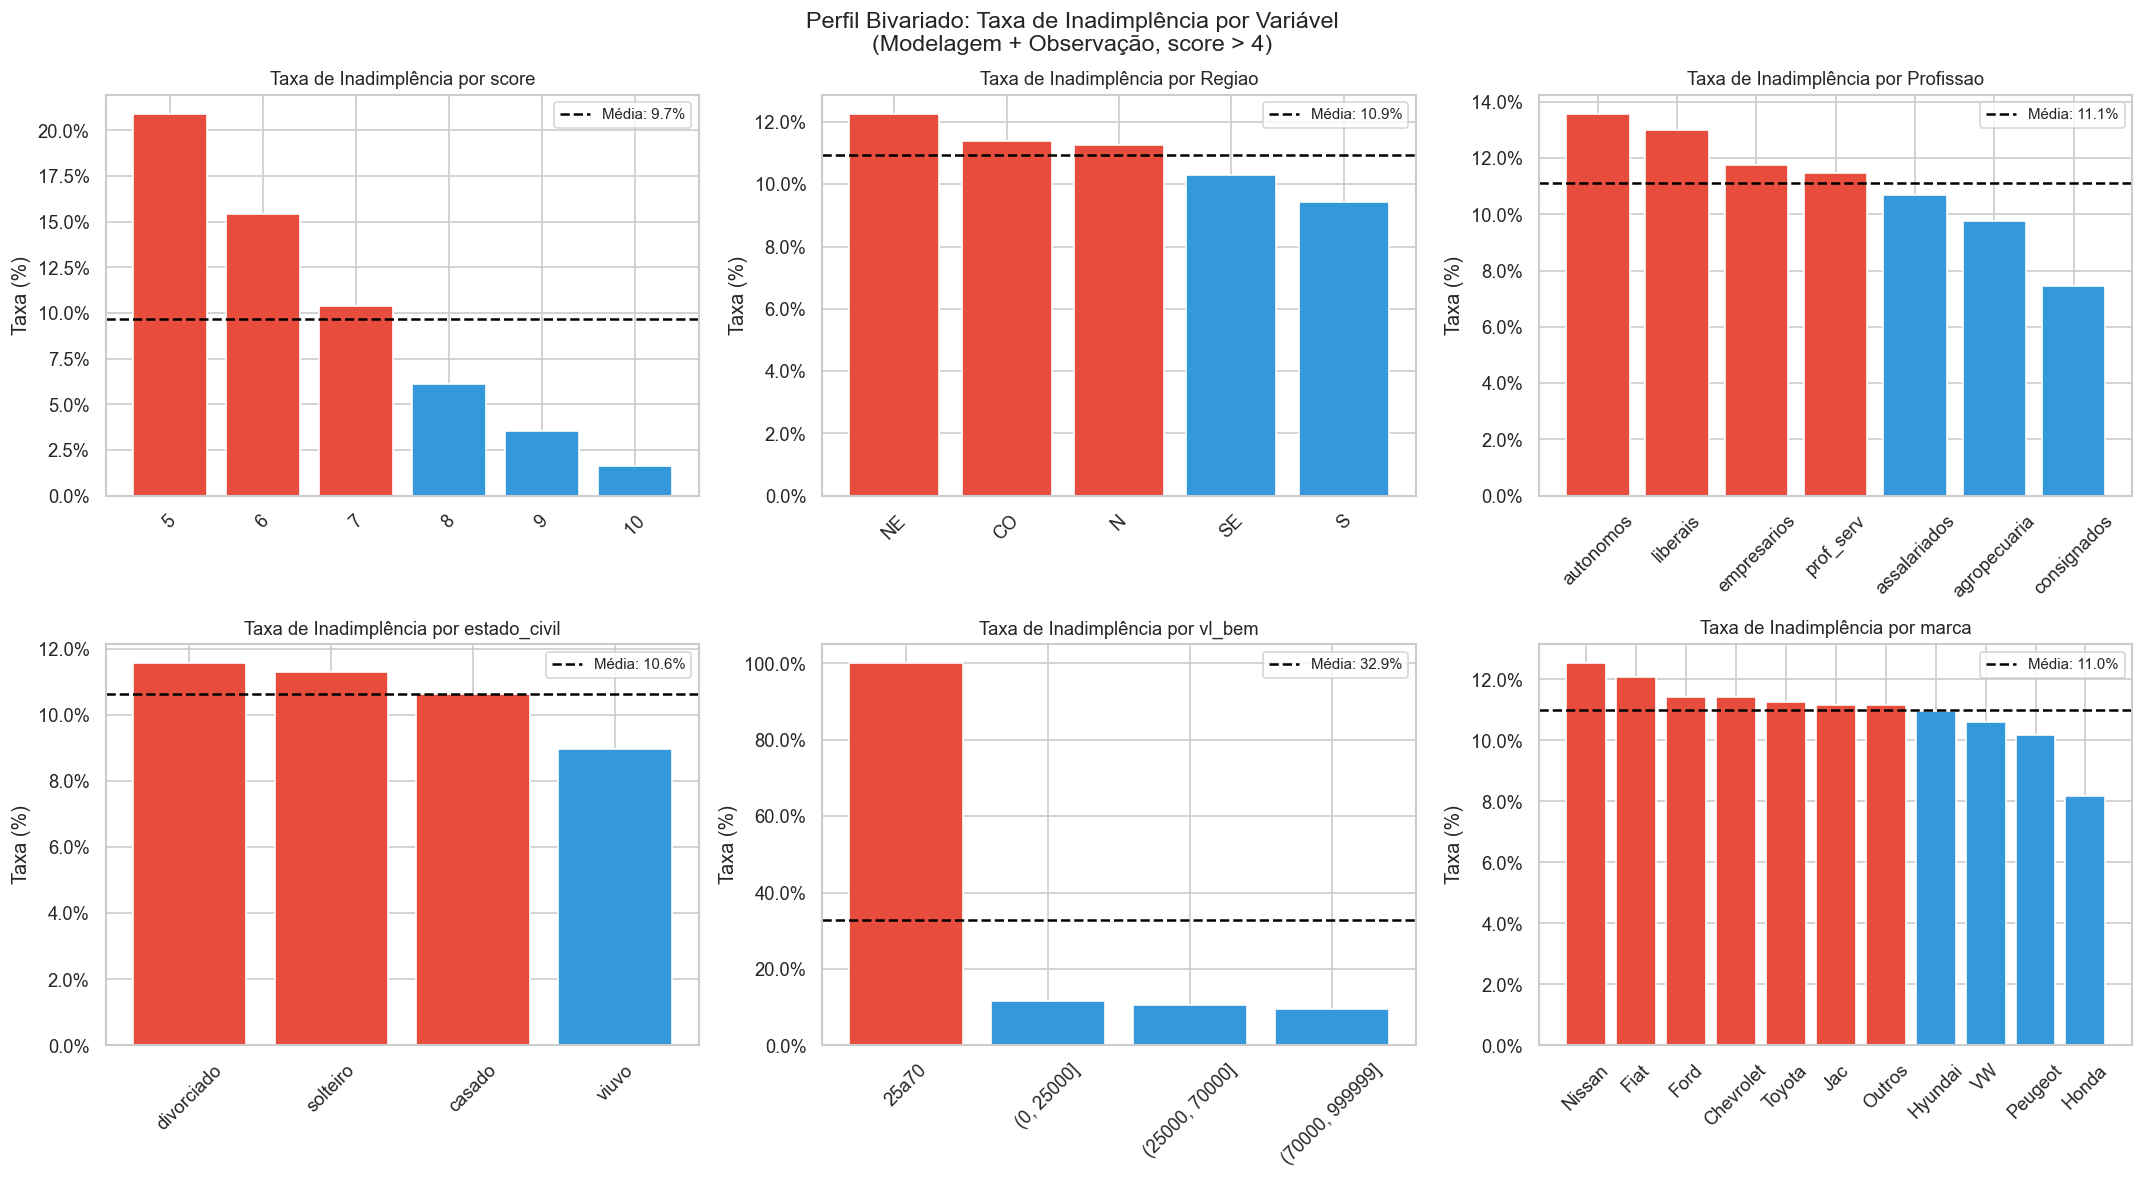

In [23]:
# Taxa de inadimplência por variável categórica chave
# (apenas janela de modelagem + observação, com target válido)
df_biv = df[
    (df['contratado'] == 1) &
    (df['target'].notna()) &
    (df['score'] > SCORE_MINIMO) &
    (df['ano_mes'] < DT_VAZIO_INICIO)
].copy()

variaveis_biv = ['score', 'Regiao', 'Profissao', 'estado_civil', 'vl_bem', 'marca']
fig, axes     = plt.subplots(2, 3, figsize=(18, 10))

for ax, var in zip(axes.flat, variaveis_biv):
    taxa = (df_biv.groupby(var)['target']
                  .agg(inadimplencia=lambda s: (s==1).sum(),
                       total=lambda s: s.notna().sum())
                  .assign(taxa_inad=lambda d: d['inadimplencia']/d['total'])
                  .reset_index()
                  .sort_values('taxa_inad', ascending=False))

    cores_biv = ['#E74C3C' if v > taxa['taxa_inad'].mean() else '#3498DB'
                 for v in taxa['taxa_inad']]
    bars = ax.bar(taxa[var].astype(str), taxa['taxa_inad']*100,
                  color=cores_biv, edgecolor='white')
    ax.axhline(taxa['taxa_inad'].mean()*100, color='black',
               linestyle='--', lw=1.5, label=f'Média: {taxa["taxa_inad"].mean()*100:.1f}%')
    ax.set_title(f'Taxa de Inadimplência por {var}', fontsize=11)
    ax.set_ylabel('Taxa (%)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1f}%'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

plt.suptitle('Perfil Bivariado: Taxa de Inadimplência por Variável\n(Modelagem + Observação, score > 4)', fontsize=14)
plt.tight_layout()
plt.show()


## 1.5. Resumo — Os 10 Easter Eggs

| #  | Descoberto em | Tipo | Descrição | Ação Recomendada |
|----|--------------|------|-----------|-----------------|
| 1  | §1.1 Tipos   | Tipo de dado | `qt_restr` e `idade_veiculo` tipadas como `object` | Mapear `'>2'`→3 e converter para `int`/`category` |
| 2  | §1.1 Valores | Dado inválido | `vl_bem = '25a70'` — 1 registro com categoria inexistente | Remover antes do treino; corrigir na pipeline de entrada |
| 3  | §1.1 Chaves  | Chave duplicada | 347 IDs com 2 ocorrências distintas | Deduplicar com `drop_duplicates(subset=['id','ano_mes'])` |
| 4  | §1.2 Temporal | Quebra estrutural | Queda permanente de ~40% no volume a partir de Abr/25 | Tratar Abr/25+ como sub-período; ampliar IC das cartas |
| 5  | §1.2 Temporal | Anomalia temporal | Spike de aprovação +10 p.p. Out/24–Mar/25 | Excluir das análises de discriminação; reavaliar em Jul/26 |
| 6  | §1.2 Temporal | Janela de target | Target exige 12 meses de maturação | Não usar Jan/25+ como janela de avaliação de inadimplência |
| 7  | §1.2 Temporal | Viés de sobrevivência | Jan/25+: `target=1` = 0 artificialmente | Idem ao Egg #6 — aguardar maturação completa |
| 8  | §1.2 Temporal | Período de limbo | Mar/24–Abr/24: transição entre modelos | Excluir do cálculo da janela de referência do PSI |
| 9  | §1.3 Score   | Política descontinuada | Scores 1–4 presentes em produção | Filtrar `score > SCORE_MINIMO (4)` em todas as métricas |
| 10 | §1.4 FPD     | Inconsistência lógica | FPD=1 com target=0: 85,6% dos FPD=1 | Reportar FPD e target com janelas distintas e separadas |

> Os eggs estão numerados pela **ordem em que são descobertos durante a exploração**,
> que é a sequência natural de uma análise de qualidade de dados.


# 2. Métricas de Monitoramento

1. **Estabilidade**:
   - Avalia se o perfil da população mudou.
2. **Discriminação**
   - Avalia se o modelo **ainda consegue separar corretamente os bons dos maus pagadores**;
   - Mede a capacidade do modelo em ordenar os clientes segundo o critério para o qual foi desenvolvido;
   - Uma queda no poder discriminatório pode indicar que as relações aprendidas pelo modelo durante o desenvolvimento não são mais válidas, comprometendo todas as decisões baseadas nele.
3. **Previsibilidade**
   - sadf


## 2.1. Estabilidade

In [24]:
# ============================================================
# SETUP DO MONITORAMENTO — compartilhado pelos Pilares 1, 2 e 3
# ============================================================
filtro_monitoramento    = (df['tipo'] == 'Adimplente') & (df['score'] > SCORE_MINIMO)
df_analise_estabilidade = df[filtro_monitoramento].copy()

dt_esperada_inicio = DT_MODELAGEM_INICIO
dt_esperada_fim    = DT_MODELAGEM_FIM
dt_observacao      = DT_OBSERVACAO_PSI


In [25]:
col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela_frequencia = pd.crosstab(df_analise_estabilidade['ano_mes'], df_analise_estabilidade[col], normalize='index')
tabela_frequencia.head(2)

score,5,6,7,8,9,10
ano_mes,,,,,,
2022-03-01,0.122325,0.180032,0.289116,0.229828,0.142976,0.035723
2022-04-01,0.123748,0.183180,0.281434,0.236735,0.138647,0.036255


### 2.1.1. PSI ou IEP (Índice de Estabilidade do Populacional)

In [26]:
# Esperado = a média dos valores do período entre 2022-03 e 2023-03 (Janela de Modelagem) para cada score.
esperado = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Observado = os valores de uma data específica (ex: 2024-03) para cada score.
observado = tabela_frequencia.loc[[dt_observacao]].iloc[0]
observado

# Criar DataFrame com diferença
df_psi = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,
    'PSI': (observado - esperado) * np.log(observado / esperado) # PSI = (%Obs - %Esp) * ln(%Obs / %Esp)
})

PSI = df_psi['PSI'].sum()


In [27]:
df_psi.T

score,5,6,7,8,9,10
Esperado,0.123268,0.183160,0.282648,0.235614,0.140345,0.034965
Observado,0.123948,0.179993,0.286452,0.241272,0.137728,0.030606
PSI,0.000004,0.000055,0.000051,0.000134,0.000049,0.000580


C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\3275166193.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


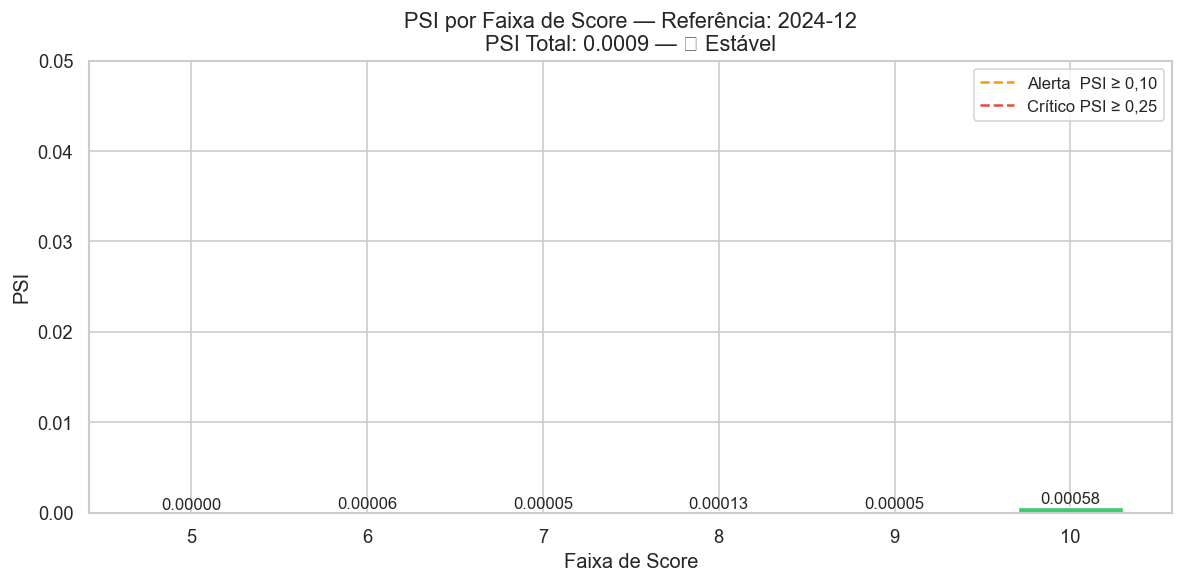

In [28]:
# PSI Waterfall — padrão de mercado para apresentação de estabilidade
fig, ax = plt.subplots(figsize=(10, 5))
cores_psi = ['#3ECC71' if v < 0.10 else '#F39C12' if v < 0.25 else '#E74C3C'
             for v in df_psi['PSI']]
barras = ax.bar(df_psi.index.astype(str), df_psi['PSI'],
                color=cores_psi, edgecolor='white', linewidth=0.8, width=0.6)

# Anotações de valor
for barra, val in zip(barras, df_psi['PSI']):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.00002,
            f'{val:.5f}', ha='center', va='bottom', fontsize=10)

ax.axhline(0.10, color='#F39C12', linestyle='--', linewidth=1.5, label='Alerta  PSI ≥ 0,10')
ax.axhline(0.25, color='#E74C3C', linestyle='--', linewidth=1.5, label='Crítico PSI ≥ 0,25')

ax.set_xlabel('Faixa de Score', fontsize=12)
ax.set_ylabel('PSI', fontsize=12)
ax.set_title(f'PSI por Faixa de Score — Referência: {DT_OBSERVACAO_PSI[:7]}\n'
             f'PSI Total: {PSI:.4f} — {"✅ Estável" if PSI < 0.10 else "⚠️ Alerta" if PSI < 0.25 else "🚨 Crítico"}',
             fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(df_psi['PSI'].max() * 1.3, 0.05))
plt.tight_layout()
plt.show()


### 2.1.2. Carta de Controle

#### 2.1.2.1. Controle do observado (dentro dos limites esperados por score)

In [29]:
# Carta de controle do observado
esperado_std = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].std()

# Criar DataFrame com diferença
df_controle = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,        
    'LS': (esperado + SIGMA_CONTROLE * esperado_std), # Limite Superior = Esperado + 2 * Desvio Padrão
    'LI': (esperado - SIGMA_CONTROLE * esperado_std),  # Limite Inferior = Esperado - 2 * Desvio Padrão
    'Cruzou?': (observado > (esperado + SIGMA_CONTROLE * esperado_std)) | (observado < (esperado - SIGMA_CONTROLE * esperado_std))
})

df_controle.T
# Limites Shewhart ±3σ: P(falso alarme) ≈ 0,3% por ponto


score,5,6,7,8,9,10
Esperado,0.123268,0.18316,0.282648,0.235614,0.140345,0.034965
Observado,0.123948,0.179993,0.286452,0.241272,0.137728,0.030606
LS,0.131693,0.197334,0.294431,0.250818,0.148467,0.039608
LI,0.114844,0.168985,0.270866,0.22041,0.132222,0.030322
Cruzou?,False,False,False,False,False,False


C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\4009720526.py:38: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Local\Temp\ipykernel_20336\4009720526.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kelly.Fonseca\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


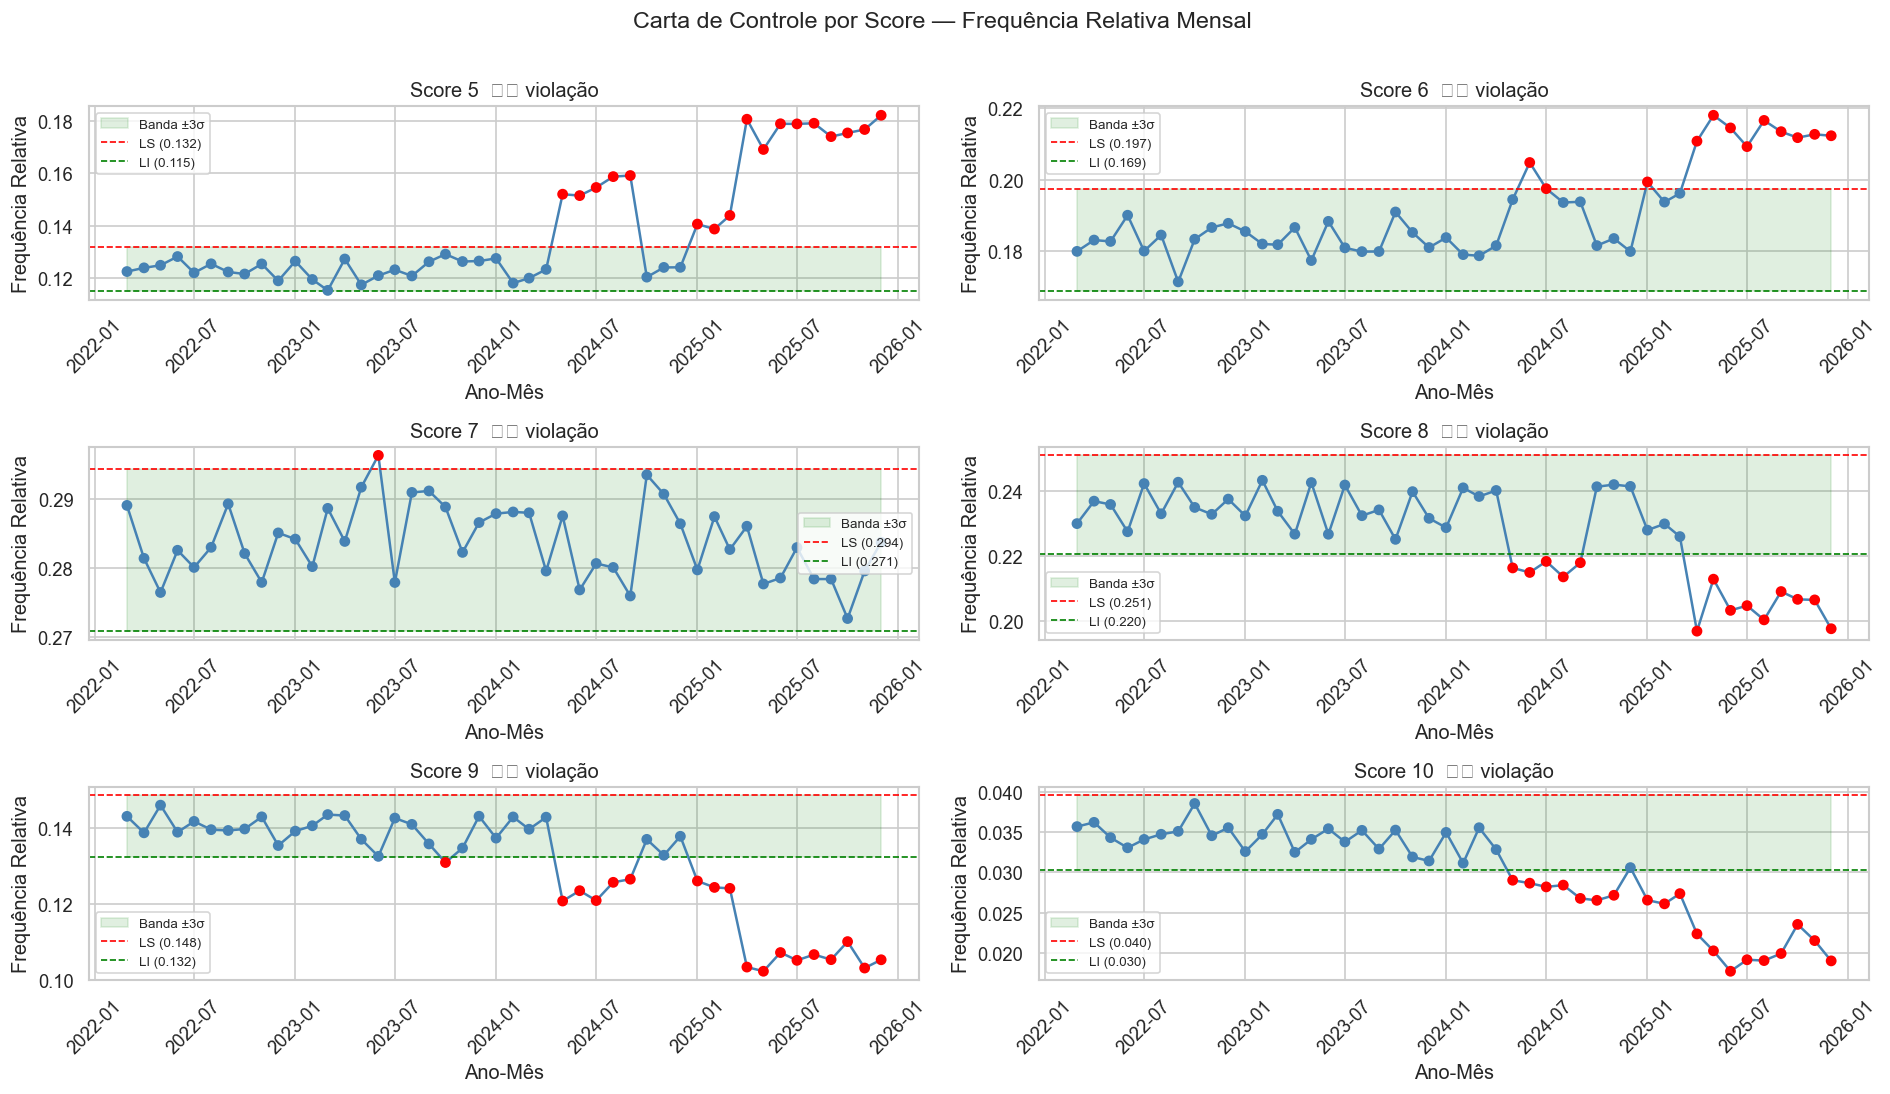

In [30]:
scores = df_controle.index.to_list()
n_scores = len(scores)
n_colunas = 2
n_linhas = (n_scores + n_colunas - 1) // n_colunas

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(16, 3 * n_linhas))
axes = axes.flatten()

for i, score in enumerate(scores):
    ax = axes[i]
    serie = tabela_frequencia[score]

    ls_val = df_controle.loc[score, 'LS']
    li_val = df_controle.loc[score, 'LI']

    # Área de controle
    ax.fill_between(serie.index, li_val, ls_val, alpha=0.12, color='green', label='Banda ±3σ')

    # Linha observada
    cores_pts = ['red' if (v > ls_val or v < li_val) else 'steelblue' for v in serie.values]
    ax.plot(serie.index, serie.values, color='steelblue', linewidth=1.5, zorder=2)
    ax.scatter(serie.index, serie.values, c=cores_pts, zorder=3, s=30)

    ax.axhline(ls_val, color='red',   linestyle='--', linewidth=1, label=f'LS ({ls_val:.3f})')
    ax.axhline(li_val, color='green', linestyle='--', linewidth=1, label=f'LI ({li_val:.3f})')

    violacoes = (serie > ls_val) | (serie < li_val)
    ax.set_title(f'Score {score}{"  ⚠️ violação" if violacoes.any() else ""}')
    ax.set_xlabel('Ano-Mês')
    ax.set_ylabel('Frequência Relativa')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Carta de Controle por Score — Frequência Relativa Mensal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


#### 2.1.2.2. Controle da variação média ponderada por score

In [33]:
# Carta de Controle

# Média ponderada do score por mês (soma produto = frequência * score)
scores = tabela_frequencia.columns.to_list()
media_ponderada_score_por_mes = tabela_frequencia.dot(scores)

# Desvio padrão do período da janela de modelagem (2022-03 a 2023-02)
std_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].std() 
mean_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Adicionar limites de controle
limite_superior = mean_ponderado_esperado + SIGMA_CONTROLE * std_ponderado_esperado # Limite Superior
limite_inferior = mean_ponderado_esperado - SIGMA_CONTROLE * std_ponderado_esperado # Limite Inferior

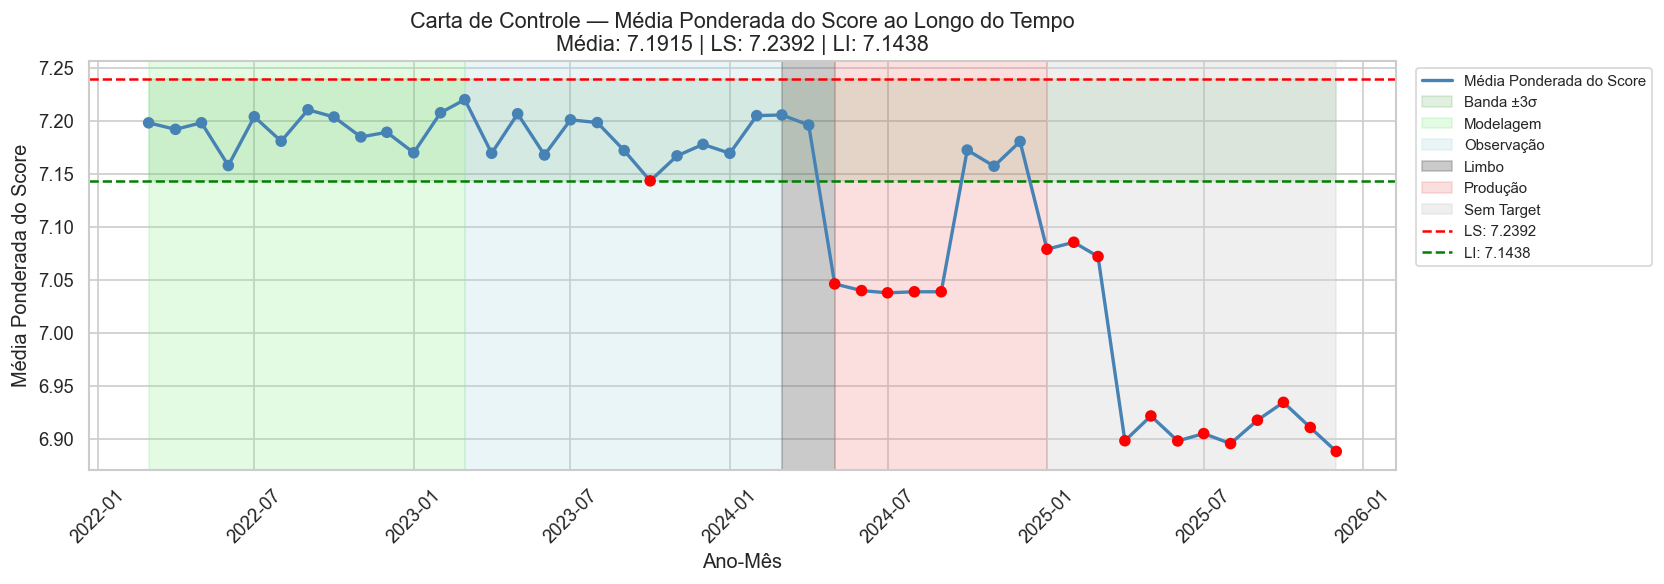

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))

# Linha e pontos — plotar primeiro para estabelecer o eixo como datetime
# colorir violações em vermelho
violacoes_idx = media_ponderada_score_por_mes[(media_ponderada_score_por_mes > limite_superior) |
                                               (media_ponderada_score_por_mes < limite_inferior)].index
cores_pts = ['red' if idx in violacoes_idx else 'steelblue'
             for idx in media_ponderada_score_por_mes.index]

ax.plot(media_ponderada_score_por_mes.index, media_ponderada_score_por_mes.values,
        color='steelblue', linewidth=2, label='Média Ponderada do Score', zorder=3)
ax.scatter(media_ponderada_score_por_mes.index, media_ponderada_score_por_mes.values,
           c=cores_pts, s=35, zorder=4)

# Área de controle (após plot para manter eixo datetime)
ax.fill_between(media_ponderada_score_por_mes.index,
                limite_inferior, limite_superior,
                alpha=0.12, color='green', label='Banda ±3σ')

# Pintar fundo por janela (usa pd.Timestamp para manter consistência com eixo datetime)
ax.axvspan(pd.Timestamp(DT_MODELAGEM_INICIO),  pd.Timestamp(DT_OBSERVACAO_INICIO), color=COR_MODELAGEM,  alpha=0.25, label='Modelagem')
ax.axvspan(pd.Timestamp(DT_OBSERVACAO_INICIO), pd.Timestamp(DT_LIMBO_INICIO),      color=COR_OBSERVACAO, alpha=0.25, label='Observação')
ax.axvspan(pd.Timestamp(DT_LIMBO_INICIO),      pd.Timestamp(DT_PRODUCAO_INICIO),   color=COR_LIMBO,      alpha=0.35, label='Limbo')
ax.axvspan(pd.Timestamp(DT_PRODUCAO_INICIO),   pd.Timestamp(DT_VAZIO_INICIO),      color=COR_PRODUCAO,   alpha=0.25, label='Produção')
ax.axvspan(pd.Timestamp(DT_VAZIO_INICIO),      media_ponderada_score_por_mes.index.max(), color=COR_VAZIO, alpha=0.35, label='Sem Target')

ax.axhline(y=limite_superior, color='red',   linestyle='--', linewidth=1.5,
           label=f'LS: {limite_superior:.4f}')
ax.axhline(y=limite_inferior, color='green', linestyle='--', linewidth=1.5,
           label=f'LI: {limite_inferior:.4f}')

ax.set_title(f'Carta de Controle — Média Ponderada do Score ao Longo do Tempo\n'
             f'Média: {mean_ponderado_esperado:.4f} | LS: {limite_superior:.4f} | LI: {limite_inferior:.4f}',
             fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Média Ponderada do Score')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()


## 2.2. Discriminação (Previsão)

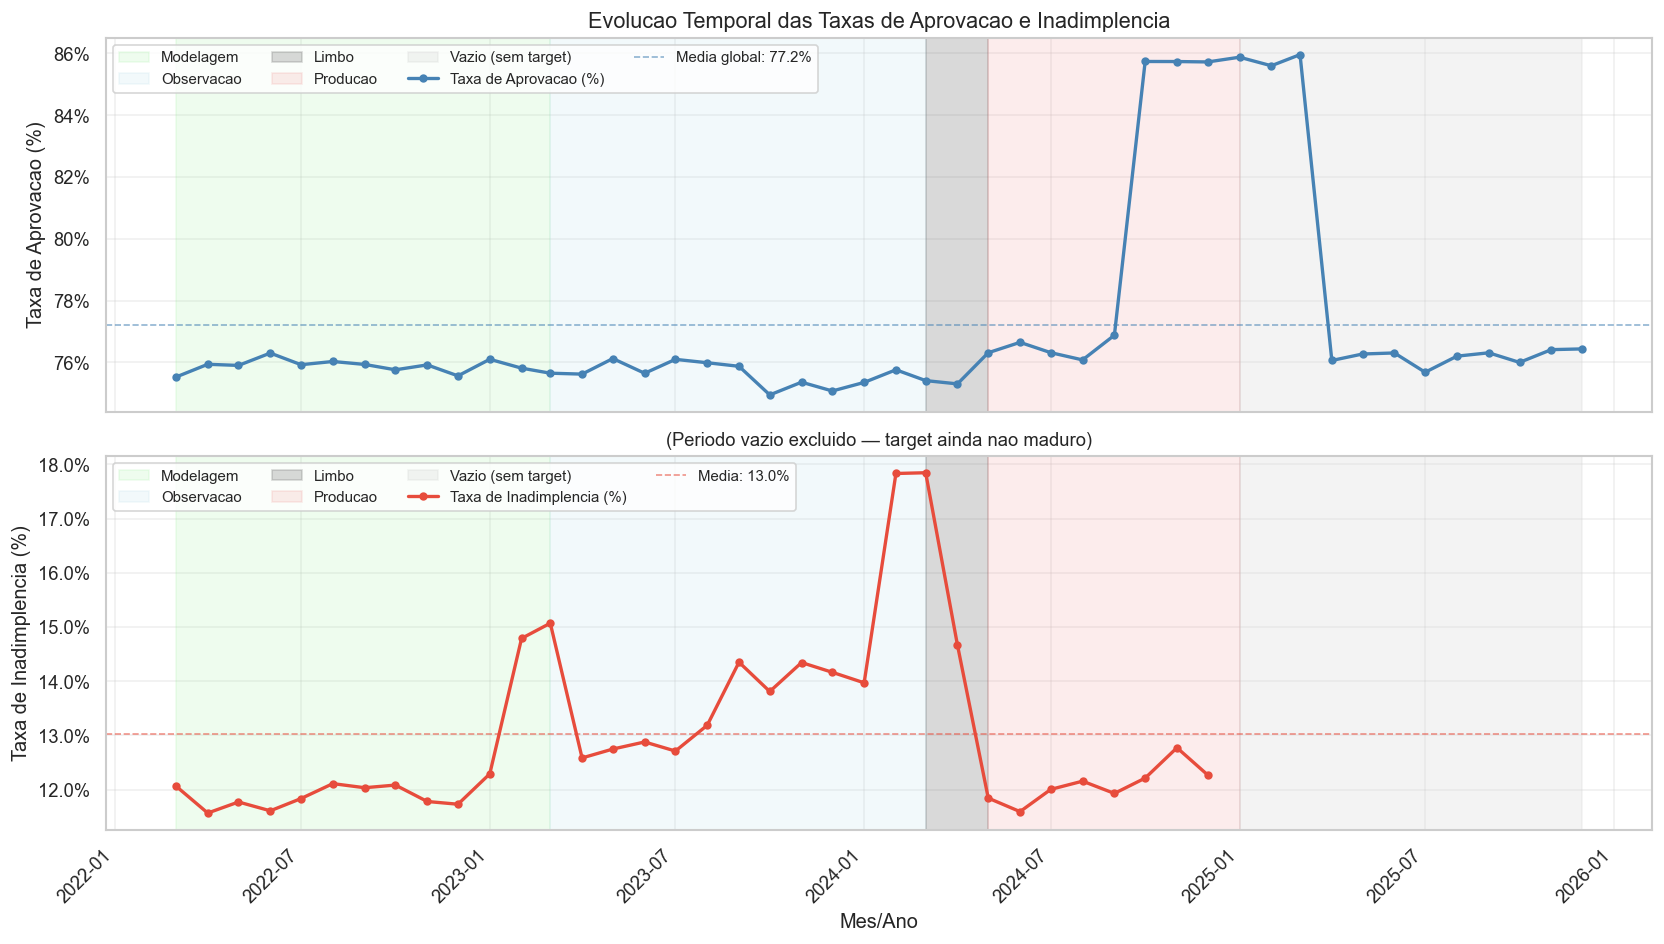

In [35]:
# Criar tabela dinâmica com % média de contratado == 1 e % média de target == 1 (entre os contratados)
tabela_contratado = df.groupby('ano_mes')['contratado'].mean().reset_index()
tabela_contratado.columns = ['ano_mes', '%_media_aprovado']

tabela_target = df[df['contratado'] == 1].groupby('ano_mes')['target'].mean().reset_index()
tabela_target.columns = ['ano_mes', '%_media_inadimplente']

tabela_fpd = df.groupby('ano_mes')['FPD'].mean().reset_index()
tabela_fpd.columns = ['ano_mes', '%_media_fpd']

tabela_dinamica = pd.merge(tabela_contratado, tabela_target, on='ano_mes', how='left')
tabela_dinamica = pd.merge(tabela_dinamica, tabela_fpd, on='ano_mes', how='left')

# ── Gráfico de linha — estilo professor: evolução temporal das taxas ─────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Janelas (timestamps)
janelas = {k: pd.Timestamp(v) for k, v in {
    'modelagem_inicio' : DT_MODELAGEM_INICIO,
    'observacao_inicio': DT_OBSERVACAO_INICIO,
    'limbo_inicio'     : DT_LIMBO_INICIO,
    'producao_inicio'  : DT_PRODUCAO_INICIO,
    'vazio_inicio'     : DT_VAZIO_INICIO,
}.items()}
tmax = pd.Timestamp(tabela_dinamica['ano_mes'].max())

def pintar(ax):
    ax.axvspan(janelas['modelagem_inicio'],  janelas['observacao_inicio'], color=COR_MODELAGEM,  alpha=0.15, label='Modelagem')
    ax.axvspan(janelas['observacao_inicio'], janelas['limbo_inicio'],      color=COR_OBSERVACAO, alpha=0.15, label='Observacao')
    ax.axvspan(janelas['limbo_inicio'],      janelas['producao_inicio'],   color=COR_LIMBO,      alpha=0.25, label='Limbo')
    ax.axvspan(janelas['producao_inicio'],   janelas['vazio_inicio'],      color=COR_PRODUCAO,   alpha=0.15, label='Producao')
    ax.axvspan(janelas['vazio_inicio'],      tmax,                         color=COR_VAZIO,      alpha=0.25, label='Vazio (sem target)')

# Painel 1 — Taxa de Aprovação
pintar(ax1)
ax1.plot(tabela_dinamica['ano_mes'], tabela_dinamica['%_media_aprovado'] * 100,
         '-o', color='steelblue', lw=2, markersize=4, label='Taxa de Aprovacao (%)')
media_aprov = tabela_dinamica['%_media_aprovado'].mean() * 100
ax1.axhline(media_aprov, color='steelblue', lw=1, linestyle='--', alpha=0.6,
            label=f'Media global: {media_aprov:.1f}%')
ax1.set_ylabel('Taxa de Aprovacao (%)')
ax1.set_title('Evolucao Temporal das Taxas de Aprovacao e Inadimplencia', fontsize=13)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax1.legend(loc='upper left', fontsize=9, ncol=4)
ax1.grid(True, alpha=0.3)

# Painel 2 — Taxa de Inadimplência (apenas ate DT_VAZIO_INICIO)
tabela_target_valida = tabela_dinamica[tabela_dinamica['ano_mes'] < janelas['vazio_inicio']]
pintar(ax2)
ax2.plot(tabela_target_valida['ano_mes'], tabela_target_valida['%_media_inadimplente'] * 100,
         '-o', color='#E74C3C', lw=2, markersize=4, label='Taxa de Inadimplencia (%)')
media_inad = tabela_target_valida['%_media_inadimplente'].mean() * 100
ax2.axhline(media_inad, color='#E74C3C', lw=1, linestyle='--', alpha=0.6,
            label=f'Media: {media_inad:.1f}%')
ax2.set_ylabel('Taxa de Inadimplencia (%)')
ax2.set_xlabel('Mes/Ano')
ax2.set_title('(Periodo vazio excluido — target ainda nao maduro)', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax2.legend(loc='upper left', fontsize=9, ncol=4)
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [36]:
# Taxas médias de aprovação e inadimplência
media_inadimplencia = tabela_dinamica[
    tabela_dinamica['ano_mes'] < '2025-01-01'
]['%_media_inadimplente'].mean()

display(pd.DataFrame({
    'Metrica': [
        '% Media de Aprovacao (ate 2025-12)',
        '% Media de Inadimplencia (ate 2024-12)',
    ],
    'Valor': [
        f"{tabela_dinamica['%_media_aprovado'].mean() * 100:.2f}%",
        f"{media_inadimplencia * 100:.2f}%",
    ]
}).set_index('Metrica'))


,Valor
Metrica,
% Media de Aprovacao (ate 2025-12),77.21%
% Media de Inadimplencia (ate 2024-12),13.02%


**Métricas**
1. KS: 
   - Se propõe a ordenar;
   - Mede a maior distanância entre clientes bons e maus;
2. ROC: 
   - 
3. Gini: 
   - 

### 2.2.1. KS

In [37]:
filtro_ks = ((df['ano_mes'] >= DT_MODELAGEM_INICIO) &
             (df['ano_mes'] <= DT_MODELAGEM_FIM) &
             (df['score'] > SCORE_MINIMO))
y_target = df[filtro_ks]['target'].values
y_score  = df[filtro_ks]['score'].values
ks, p_value = calcular_ks(y_target, y_score)
print(f"KS (Janela de Modelagem): {ks:.4f} | p-valor: {p_value:.4e}")


KS (Janela de Modelagem): 0.2554 | p-valor: 0.0000e+00


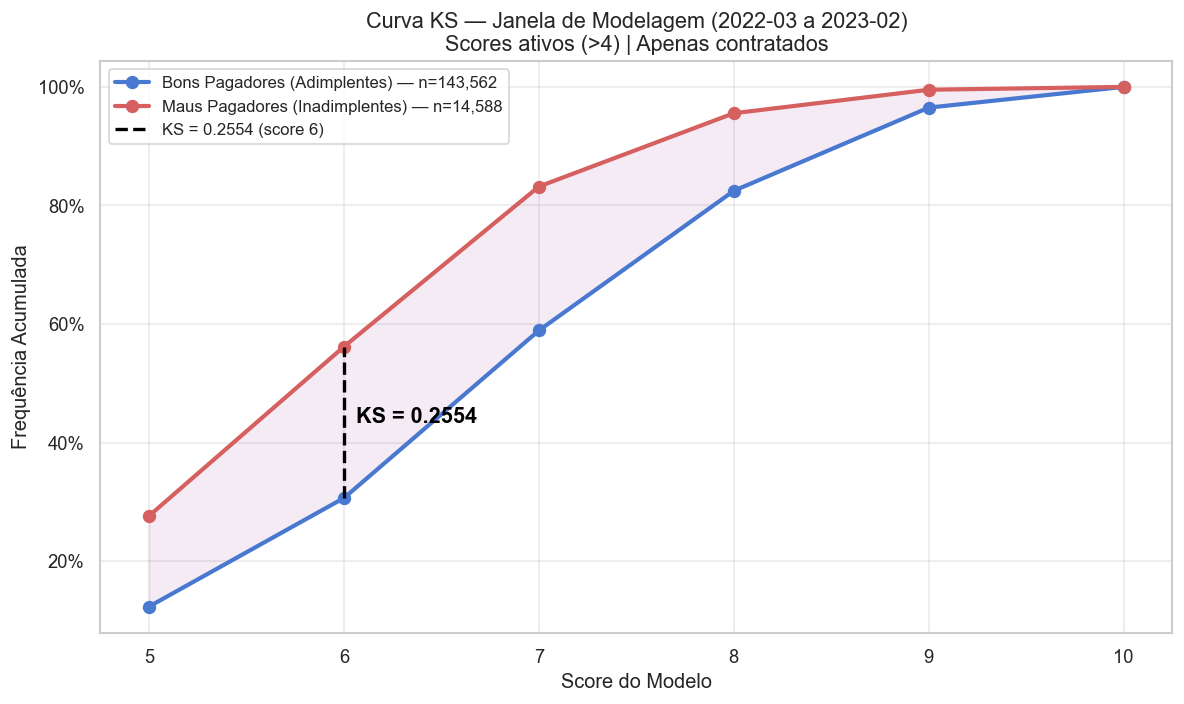

In [38]:
# Curva KS — padrão de mercado em crédito
# Mostra distribuição acumulada de bons e maus pagadores por faixa de score
df_modelagem_ks = df[
    (df['ano_mes'] >= DT_MODELAGEM_INICIO) &
    (df['ano_mes'] <= DT_MODELAGEM_FIM) &
    (df['score'] > SCORE_MINIMO) &
    (df['contratado'] == 1)
].copy()

scores_range = sorted(df_modelagem_ks['score'].unique())
total_bons = (df_modelagem_ks['target'] == 0).sum()
total_maus = (df_modelagem_ks['target'] == 1).sum()

cdf_bons = [((df_modelagem_ks['target'] == 0) & (df_modelagem_ks['score'] <= s)).sum() / total_bons
            for s in scores_range]
cdf_maus = [((df_modelagem_ks['target'] == 1) & (df_modelagem_ks['score'] <= s)).sum() / total_maus
            for s in scores_range]
diffs    = [abs(b - m) for b, m in zip(cdf_bons, cdf_maus)]
ks_idx   = diffs.index(max(diffs))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(scores_range, cdf_bons, 'b-o', linewidth=2.5, markersize=7,
        label=f'Bons Pagadores (Adimplentes) — n={total_bons:,}')
ax.plot(scores_range, cdf_maus, 'r-o', linewidth=2.5, markersize=7,
        label=f'Maus Pagadores (Inadimplentes) — n={total_maus:,}')

ax.vlines(scores_range[ks_idx],
          min(cdf_bons[ks_idx], cdf_maus[ks_idx]),
          max(cdf_bons[ks_idx], cdf_maus[ks_idx]),
          color='black', linestyle='--', linewidth=2,
          label=f'KS = {max(diffs):.4f} (score {scores_range[ks_idx]})')

mid_y = (cdf_bons[ks_idx] + cdf_maus[ks_idx]) / 2
ax.annotate(f'  KS = {max(diffs):.4f}',
            xy=(scores_range[ks_idx], mid_y),
            fontsize=13, fontweight='bold', color='black')

ax.fill_between(scores_range, cdf_bons, cdf_maus, alpha=0.08, color='purple')

ax.set_xlabel('Score do Modelo', fontsize=12)
ax.set_ylabel('Frequência Acumulada', fontsize=12)
ax.set_title(f'Curva KS — Janela de Modelagem ({DT_MODELAGEM_INICIO[:7]} a {DT_MODELAGEM_FIM[:7]})\n'
             f'Scores ativos (>{SCORE_MINIMO}) | Apenas contratados', fontsize=13)
ax.set_xticks(scores_range)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


#### 2.2.1.2. KS Passo a passo - Didático, como o da aula do Danilo

- É a tabela de frequência acumulada por ano_mes ao longo dos scores

In [39]:
# Selecionar as informações para análise
filtro = ((df['ano_mes'] >= '2022-03-01') & 
          (df['ano_mes'] <= '2023-02-01') & 
          (df['score'] > 4) &
          (df['contratado']  == 1) &
          (df['target'] == 0))
df_bons_pagadores = df[filtro].copy()

# Selecionar as datas para análise de PSI 
#dt_esperada_inicio = '2022-03-01' # Início da Janela de Modelagem
#dt_esperada_fim    = '2023-02-01' # Fim da Janela de Modelagem
#dt_observacao      = '2024-12-01' # Data da análise

col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela = pd.crosstab(df_bons_pagadores['ano_mes'], 
                     df_bons_pagadores[col], 
                     normalize='index')

# Calcular distribuição acumulada (cumsum) ao longo dos scores
tabela_acumulada_bons_pagadores = tabela.cumsum(axis=1)

tabela_acumulada_bons_pagadores.T

ano_mes,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01
score,,,,,,,,,,,,
5,0.122325,0.123748,0.124736,0.128086,0.121849,0.125302,0.122160,0.121388,0.125260,0.118768,0.126313,0.119286
6,0.302357,0.306928,0.307537,0.318178,0.301964,0.309879,0.293703,0.304799,0.311943,0.306614,0.311875,0.301363
7,0.591473,0.588362,0.584016,0.600781,0.582079,0.592914,0.583047,0.586931,0.589882,0.591741,0.596101,0.581594
8,0.821301,0.825097,0.819732,0.828111,0.824223,0.825761,0.825606,0.821737,0.822569,0.829109,0.828305,0.824737
9,0.964277,0.963745,0.965651,0.966919,0.965876,0.965236,0.964870,0.961392,0.965414,0.964412,0.967392,0.965241
10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [40]:
# Selecionar as informações para análise
filtro = ((df['ano_mes'] >= '2022-03-01') & 
          (df['ano_mes'] <= '2023-02-01') & 
          (df['score'] > 4) &
          (df['contratado']  == 1) &
          (df['target'] == 1))
df_maus_pagadores = df[filtro].copy()

col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela = pd.crosstab(df_maus_pagadores['ano_mes'], 
                     df_maus_pagadores[col], 
                     normalize='index')

# Calcular distribuição acumulada (cumsum) ao longo dos scores
tabela_acumulada_maus_pagadores = tabela.cumsum(axis=1)

tabela_acumulada_maus_pagadores.T

ano_mes,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01
score,,,,,,,,,,,,
5,0.270492,0.274956,0.299563,0.266724,0.272364,0.283003,0.275459,0.282137,0.275563,0.273271,0.284903,0.261682
6,0.590984,0.563923,0.575546,0.566895,0.522364,0.575083,0.565943,0.565109,0.548527,0.586678,0.544643,0.543391
7,0.856557,0.832750,0.818341,0.823328,0.817093,0.859736,0.835559,0.834725,0.837955,0.832622,0.815747,0.821095
8,0.962295,0.963222,0.951092,0.949400,0.959265,0.967822,0.959933,0.948247,0.953206,0.968403,0.943182,0.943925
9,0.995902,0.996497,0.992140,0.993997,0.993610,0.998350,0.995826,0.994992,0.995667,0.997438,0.995942,0.992657
10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
# Alinhar índices e colunas antes da diferença
# (necessário pois alguns meses podem não ter maus pagadores em todos os scores)
cols_comuns = tabela_acumulada_bons_pagadores.columns.intersection(
                  tabela_acumulada_maus_pagadores.columns)
idx_comuns  = tabela_acumulada_bons_pagadores.index.intersection(
                  tabela_acumulada_maus_pagadores.index)

tabela_diferenca_ks = abs(
    tabela_acumulada_maus_pagadores.loc[idx_comuns, cols_comuns] -
    tabela_acumulada_bons_pagadores.loc[idx_comuns, cols_comuns]
)
tabela_diferenca_ks.head()


score,5,6,7,8,9,10
ano_mes,,,,,,
2022-03-01,0.148167,0.288627,0.265084,0.140994,0.031625,1.110223e-16
2022-04-01,0.151208,0.256995,0.244388,0.138125,0.032753,2.220446e-16
2022-05-01,0.174827,0.268009,0.234325,0.131360,0.026489,1.110223e-16
2022-06-01,0.138638,0.248717,0.222546,0.121289,0.027078,0.000000e+00
2022-07-01,0.150515,0.220400,0.235014,0.135043,0.027735,0.000000e+00


In [42]:
# O KS é o valor máximo da tabela de diferenca por mes_ano
tabela_ks = tabela_diferenca_ks.max(axis=1).reset_index()
tabela_ks.columns = ['ano_mes', 'KS']

tabela_ks.head()

,ano_mes,KS
0,2022-03-01,0.288627
1,2022-04-01,0.256995
2,2022-05-01,0.268009
3,2022-06-01,0.248717
4,2022-07-01,0.235014


In [43]:
# Apenas no período da janela de modelagem (2022-03 a 2023-02)
tabela_ks_filtrada = tabela_ks[(tabela_ks['ano_mes'] >= '2022-03-01') & (tabela_ks['ano_mes'] <= '2023-02-01')]
ks_total = tabela_ks_filtrada['KS'].mean()
print(f"KS Total: {ks_total:.4f}")

KS Total: 0.2583


## 2.3. Previsibilidade

**Métricas**:
1. Observado x Esperado

### 2.3.1. Observado x Esperado (GH)

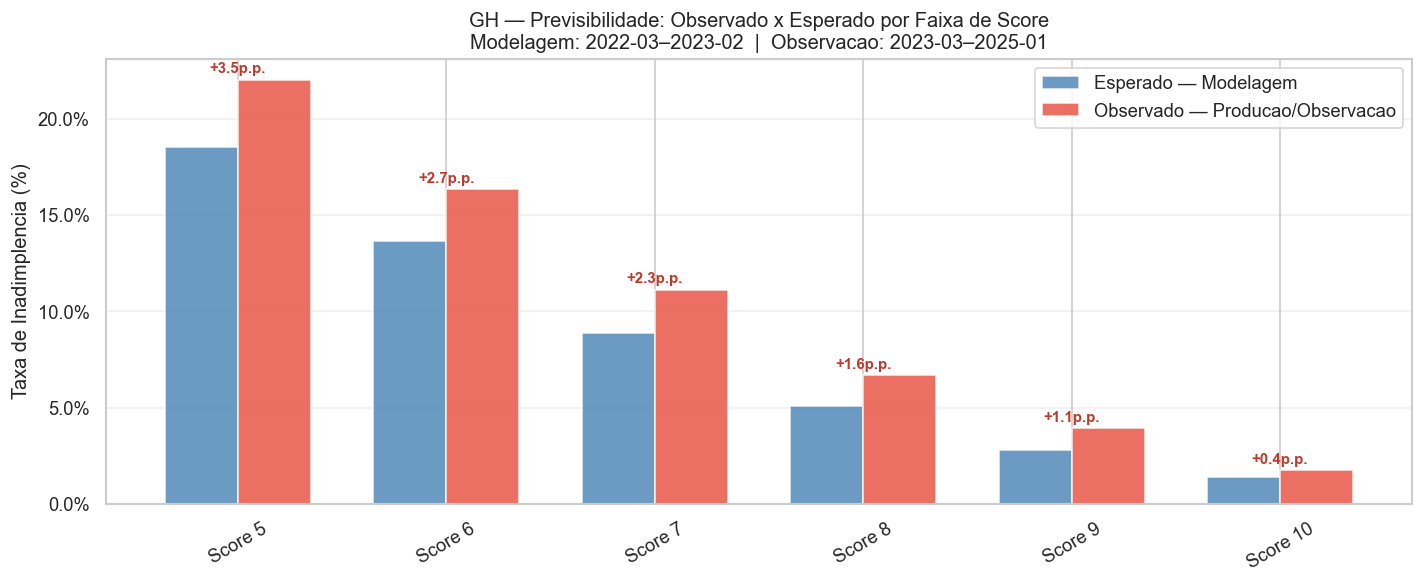

,Esperado (Modelagem),Observado (Producao),Desvio (p.p.)
score,,,
5,18.55%,22.03%,+3.48
6,13.67%,16.33%,+2.66
7,8.85%,11.13%,+2.28
8,5.06%,6.66%,+1.60
9,2.79%,3.91%,+1.12
10,1.38%,1.74%,+0.37


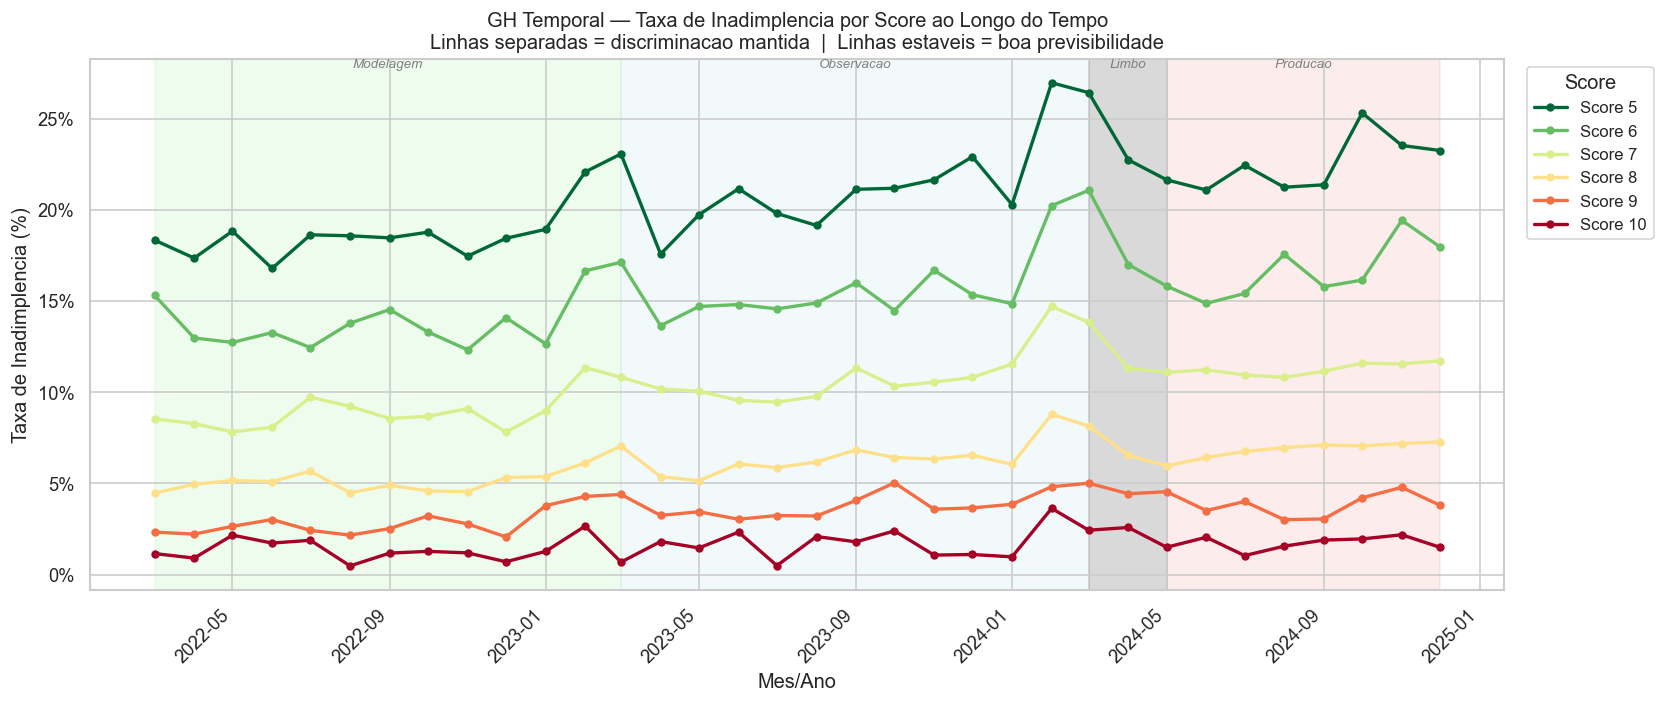

In [44]:
# GH — Observado × Esperado por faixa de score
# Esperado : taxa de inadimplência observada na janela de modelagem (baseline do modelo)
# Observado: taxa de inadimplência na janela de observação/produção

filtro_esp = (
    (df['ano_mes'] >= DT_MODELAGEM_INICIO) &
    (df['ano_mes'] <= DT_MODELAGEM_FIM) &
    (df['score'] > SCORE_MINIMO) &
    (df['contratado'] == 1) &
    (df['target'].notna())
)
filtro_obs = (
    (df['ano_mes'] >= DT_OBSERVACAO_INICIO) &
    (df['ano_mes'] < DT_VAZIO_INICIO) &
    (df['score'] > SCORE_MINIMO) &
    (df['contratado'] == 1) &
    (df['target'].notna())
)

gh_esp = (df[filtro_esp]
           .groupby('score')['target']
           .mean()
           .rename('Esperado (Modelagem)'))

gh_obs = (df[filtro_obs]
           .groupby('score')['target']
           .mean()
           .rename('Observado (Producao)'))

gh_df = pd.concat([gh_esp, gh_obs], axis=1).dropna()
gh_df['Desvio (p.p.)'] = (gh_df['Observado (Producao)'] - gh_df['Esperado (Modelagem)']) * 100

# ── Gráfico ─────────────────────────────────────────────────────────────────
x     = np.arange(len(gh_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, gh_df['Esperado (Modelagem)'] * 100,
               width, label='Esperado — Modelagem', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, gh_df['Observado (Producao)'] * 100,
               width, label='Observado — Producao/Observacao', color='#E74C3C', alpha=0.8)

# Anotações de desvio em p.p.
for xi, (_, row) in zip(x, gh_df.iterrows()):
    desvio = row['Desvio (p.p.)']
    cor    = '#C0392B' if desvio > 0 else '#27AE60'
    sinal  = '+' if desvio > 0 else ''
    ax.annotate(f'{sinal}{desvio:.1f}p.p.',
                xy=(xi, max(row['Esperado (Modelagem)'], row['Observado (Producao)']) * 100 + 0.2),
                ha='center', va='bottom', fontsize=9, color=cor, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Score {int(s)}' for s in gh_df.index], rotation=30)
ax.set_ylabel('Taxa de Inadimplencia (%)')
ax.set_title(
    'GH — Previsibilidade: Observado x Esperado por Faixa de Score\n'
    f'Modelagem: {DT_MODELAGEM_INICIO[:7]}–{DT_MODELAGEM_FIM[:7]}  |  '
    f'Observacao: {DT_OBSERVACAO_INICIO[:7]}–{DT_VAZIO_INICIO[:7]}',
    fontsize=12
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── Tabela resumo do desvio ──────────────────────────────────────────────────
display(
    gh_df.assign(**{
        'Esperado (Modelagem)': gh_df['Esperado (Modelagem)'].map('{:.2%}'.format),
        'Observado (Producao)': gh_df['Observado (Producao)'].map('{:.2%}'.format),
        'Desvio (p.p.)'       : gh_df['Desvio (p.p.)'].map('{:+.2f}'.format),
    })
)

# ── Gráfico de linha por score — estilo professor ────────────────────────────
# Mostra SIMULTANEAMENTE: discriminacao (ranking entre scores) + previsibilidade (estabilidade)
# "se as linhas mantêm a ordem mas sobem → perda de previsibilidade sem perda de discriminacao"
# "se as linhas cruzam mas ficam estáveis → perda de discriminacao com boa previsibilidade"

filtro_linha = (
    (df['score'] > SCORE_MINIMO) &
    (df['contratado'] == 1) &
    (df['target'].notna()) &
    (df['ano_mes'] < pd.Timestamp(DT_VAZIO_INICIO))
)
df_linha = df[filtro_linha].copy()

taxa_por_score_tempo = (
    df_linha.groupby(['ano_mes', 'score'])['target']
            .mean()
            .reset_index()
            .rename(columns={'target': 'taxa_inadimplencia'})
)

scores_ativos = sorted(df_linha['score'].unique())
paleta = plt.cm.RdYlGn_r(
    [(i / (len(scores_ativos) - 1)) for i in range(len(scores_ativos))]
)

fig, ax = plt.subplots(figsize=(14, 6))

# Janelas de fundo
janelas_l = {k: pd.Timestamp(v) for k, v in {
    'modelagem_inicio' : DT_MODELAGEM_INICIO,
    'observacao_inicio': DT_OBSERVACAO_INICIO,
    'limbo_inicio'     : DT_LIMBO_INICIO,
    'producao_inicio'  : DT_PRODUCAO_INICIO,
    'vazio_inicio'     : DT_VAZIO_INICIO,
}.items()}
tmax_l = pd.Timestamp(taxa_por_score_tempo['ano_mes'].max())

ax.axvspan(janelas_l['modelagem_inicio'],  janelas_l['observacao_inicio'], color=COR_MODELAGEM,  alpha=0.15, zorder=0)
ax.axvspan(janelas_l['observacao_inicio'], janelas_l['limbo_inicio'],      color=COR_OBSERVACAO, alpha=0.15, zorder=0)
ax.axvspan(janelas_l['limbo_inicio'],      janelas_l['producao_inicio'],   color=COR_LIMBO,      alpha=0.25, zorder=0)
ax.axvspan(janelas_l['producao_inicio'],   tmax_l,                         color=COR_PRODUCAO,   alpha=0.15, zorder=0)

# Uma linha por score
for score, cor in zip(scores_ativos, paleta):
    dados = taxa_por_score_tempo[taxa_por_score_tempo['score'] == score]
    ax.plot(dados['ano_mes'], dados['taxa_inadimplencia'] * 100,
            '-o', color=cor, lw=2, markersize=4, label=f'Score {int(score)}')

ax.set_xlabel('Mes/Ano')
ax.set_ylabel('Taxa de Inadimplencia (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_title(
    'GH Temporal — Taxa de Inadimplencia por Score ao Longo do Tempo\n'
    'Linhas separadas = discriminacao mantida  |  Linhas estaveis = boa previsibilidade',
    fontsize=12
)
ax.legend(title='Score', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

# Rotulos das janelas no topo
for rotulo, x_pos in [
    ('Modelagem',  janelas_l['modelagem_inicio']  + (janelas_l['observacao_inicio'] - janelas_l['modelagem_inicio'])  / 2),
    ('Observacao', janelas_l['observacao_inicio'] + (janelas_l['limbo_inicio']      - janelas_l['observacao_inicio']) / 2),
    ('Limbo',      janelas_l['limbo_inicio']      + (janelas_l['producao_inicio']   - janelas_l['limbo_inicio'])      / 2),
    ('Producao',   janelas_l['producao_inicio']   + (tmax_l                         - janelas_l['producao_inicio'])   / 2),
]:
    ax.text(x_pos, ax.get_ylim()[1] if ax.get_ylim()[1] else 20,
            rotulo, ha='center', va='top', fontsize=8, color='gray', style='italic')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### 2.3.2. FPD (First Payment Default)

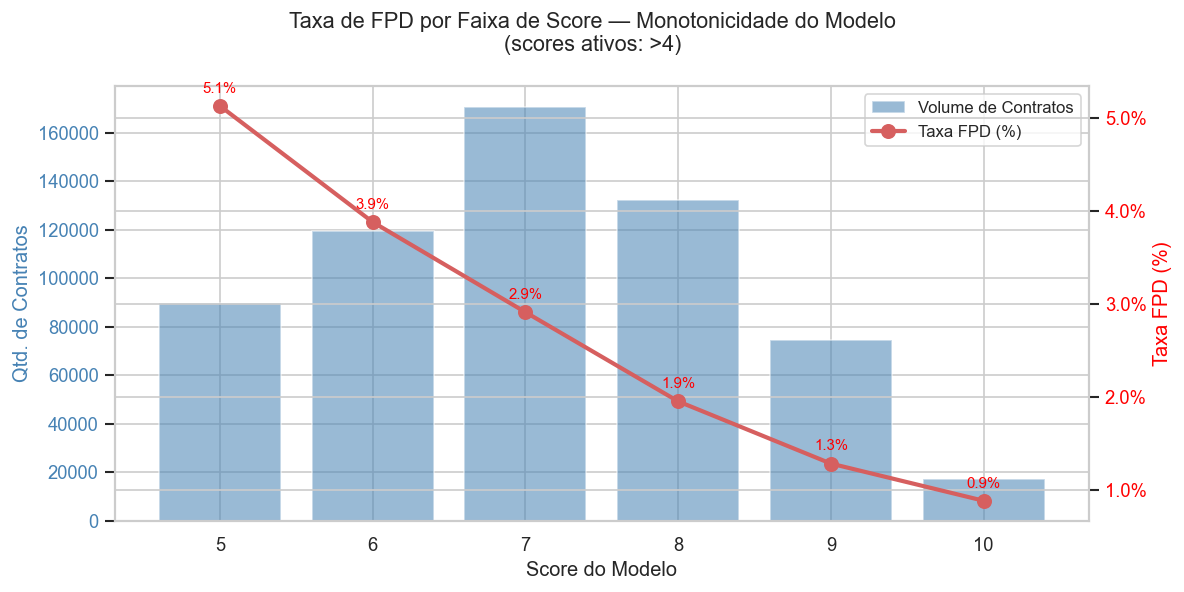

In [45]:
fpd_analysis = calcular_fpd(df)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(fpd_analysis['score'].astype(str), fpd_analysis['total_contratos'],
        color='steelblue', alpha=0.55, label='Volume de Contratos')
ax2.plot(fpd_analysis['score'].astype(str), fpd_analysis['taxa_fpd'] * 100,
         'r-o', linewidth=2.5, markersize=8, label='Taxa FPD (%)')

# Anotações de taxa
for _, row in fpd_analysis.iterrows():
    ax2.annotate(f"{row['taxa_fpd']*100:.1f}%",
                 xy=(str(int(row['score'])), row['taxa_fpd']*100),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=9, color='red')

ax1.set_xlabel('Score do Modelo', fontsize=12)
ax1.set_ylabel('Qtd. de Contratos', color='steelblue', fontsize=12)
ax2.set_ylabel('Taxa FPD (%)', color='red', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

fig.suptitle('Taxa de FPD por Faixa de Score — Monotonicidade do Modelo\n'
             f'(scores ativos: >{SCORE_MINIMO})', fontsize=13)
plt.tight_layout()
plt.show()


### 2.3.3. WOE (Weight of Evidence) e IV (Information Value)

Base WOE/IV: 469,232 registros  (10.8% inadimplência)


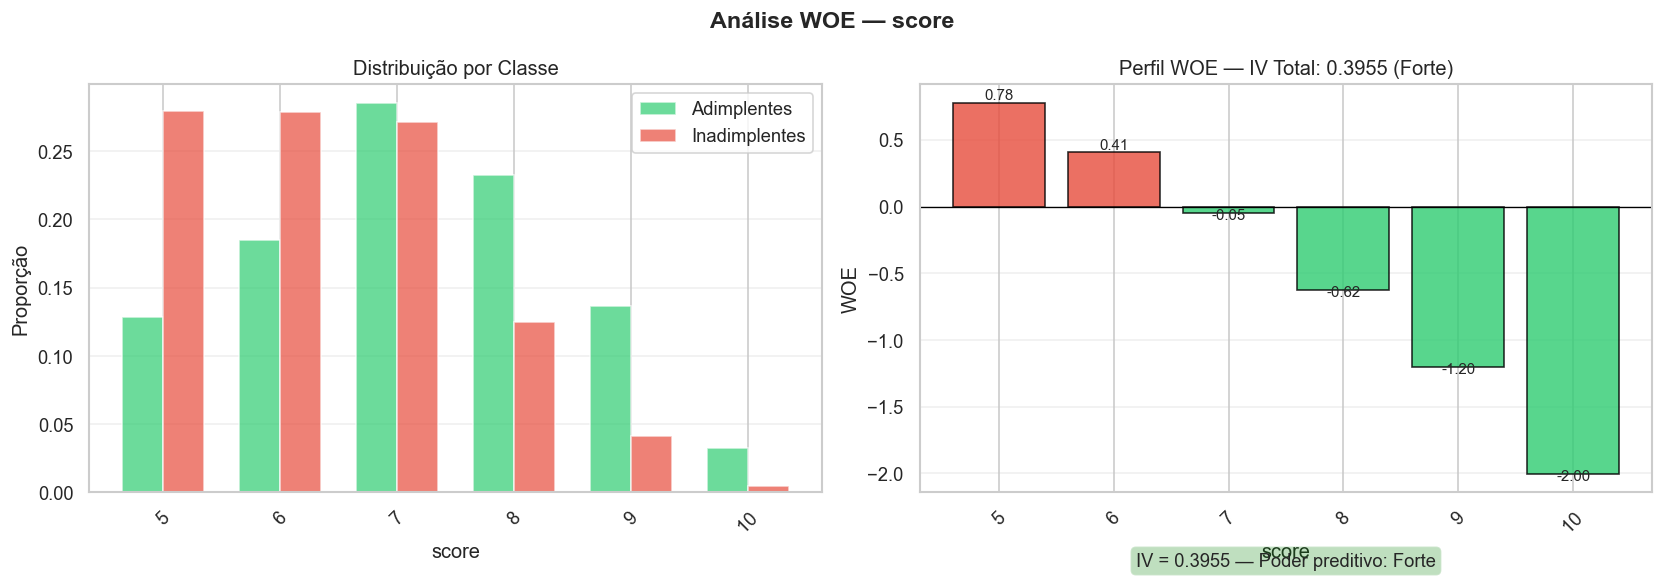

In [47]:
# calcular_woe_iv e plot_woe_analysis importadas de utils.py

# Base correta: contratados, target disponível, scores ativos, antes do período vazio
df_woe_base = df[
    (df['contratado'] == 1) &
    (df['target'].notna()) &
    (df['score'] > SCORE_MINIMO) &
    (df['ano_mes'] < DT_VAZIO_INICIO)
].copy()
print(f"Base WOE/IV: {len(df_woe_base):,} registros  ({df_woe_base['target'].mean():.1%} inadimplência)")

woe_score, iv_score = plot_woe_analysis(df_woe_base, 'score')


### 2.3.3.1. WOE/IV por Variável — Visão Geral

O WOE/IV calculado para cada variável preditora indica o **poder discriminante** individual.
Isso orienta quais variáveis ainda contribuem para separar bons e maus pagadores
na janela atual — e quais eventualmente perderam poder preditivo.

**Interpretação do IV:**
| IV | Classificação |
|----|---------------|
| < 0.02 | Não preditivo |
| 0.02 – 0.10 | Fraco |
| 0.10 – 0.30 | Médio |
| > 0.30 | Forte |

In [ ]:
# Base comum para WOE/IV: contratados, target disponível, scores ativos, antes do período vazio
# (mesma base usada para o WOE/IV do score acima)
print(f"Base WOE/IV: {len(df_woe_base):,} registros  ({df_woe_base['target'].mean():.1%} inadimplência)")


# ── Variáveis Categóricas ────────────────────────────────────────────
vars_cat = ['score', 'marca', 'Regiao', 'Profissao', 'estado_civil', 'vl_bem']

iv_resumo = {}
for var in vars_cat:
    try:
        _, iv = calcular_woe_iv(df_woe_base, var)
        iv_resumo[var] = iv
    except Exception as e:
        iv_resumo[var] = None
        print(f"  {var}: erro — {e}")

# ── Variáveis Numéricas (binadas com qcut) ───────────────────────────
vars_num = {
    'idade' : 5,
    'renda'  : 5,
    'pmt'    : 5,
    'entrada': 5,
    'prazo'  : 5,
}

for var, n_bins in vars_num.items():
    try:
        col_bin = f'{var}_bin'
        df_woe_base[col_bin] = pd.qcut(
            df_woe_base[var], q=n_bins, duplicates='drop'
        ).astype(str)
        _, iv = calcular_woe_iv(df_woe_base, col_bin)
        iv_resumo[f'{var} (binado)'] = iv
    except Exception as e:
        iv_resumo[f'{var} (binado)'] = None
        print(f"  {var}: erro — {e}")

# ── Tabela resumo de IV ──────────────────────────────────────────────
def classif_iv(iv):
    if iv is None:    return 'Erro'
    if iv < 0.02:     return 'Não preditivo'
    if iv < 0.10:     return 'Fraco'
    if iv < 0.30:     return 'Médio'
    return 'Forte'

def cor_iv(iv):
    if iv is None:    return ''
    if iv < 0.02:     return '#E74C3C'
    if iv < 0.10:     return '#E67E22'
    if iv < 0.30:     return '#3498DB'
    return '#27AE60'

iv_df = (
    pd.DataFrame.from_dict(iv_resumo, orient='index', columns=['IV'])
      .assign(Classificação=lambda d: d['IV'].apply(classif_iv))
      .sort_values('IV', ascending=False)
)
display(iv_df.assign(IV=iv_df["IV"].map("{:.4f}".format)))


In [ ]:
# Gráfico: IV de todas as variáveis — ranking de poder preditivo
iv_plot = iv_df[iv_df['IV'].notna()].copy()

cores_iv = [cor_iv(v) for v in iv_plot['IV']]

fig, ax = plt.subplots(figsize=(12, max(5, len(iv_plot)*0.45)))
bars = ax.barh(iv_plot.index, iv_plot['IV'], color=cores_iv, edgecolor='white', linewidth=0.8)

# Anotar valores
for bar, val in zip(bars, iv_plot['IV']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Linhas de referência
ax.axvline(0.02, color='#E67E22', linestyle='--', lw=1.2, label='Fraco (0.02)')
ax.axvline(0.10, color='#3498DB', linestyle='--', lw=1.2, label='Médio (0.10)')
ax.axvline(0.30, color='#27AE60', linestyle='--', lw=1.2, label='Forte (0.30)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#E74C3C', label='Não preditivo (< 0.02)'),
    Patch(facecolor='#E67E22', label='Fraco (0.02–0.10)'),
    Patch(facecolor='#3498DB', label='Médio (0.10–0.30)'),
    Patch(facecolor='#27AE60', label='Forte (> 0.30)'),
], loc='lower right', fontsize=9)

ax.set_title('IV por Variável Preditora — Ranking de Poder Discriminante\n'
             '(Base: Modelagem + Observação, score > 4, target disponível)',
             fontsize=13)
ax.set_xlabel('Information Value (IV)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 2.3.3.2. WOE/IV Detalhado por Variável

In [ ]:
# WOE/IV detalhado para cada variável — perfil de cada categoria
for var in vars_cat:
    try:
        plot_woe_analysis(df_woe_base, var)
    except Exception as e:
        print(f"Erro em {var}: {e}")

for var in vars_num.keys():
    col_bin = f'{var}_bin'
    if col_bin in df_woe_base.columns:
        try:
            plot_woe_analysis(df_woe_base, col_bin, titulo=f'WOE/IV — {var} (quintis)')
        except Exception as e:
            print(f"Erro em {var}: {e}")


# 3. Conclusão e Recomendação

Com os três pilares analisados e os 10 Easter Eggs documentados,
sintetizamos os achados em um parecer estruturado sobre o estado do modelo.

## 3.1. Semáforo de Monitoramento — Síntese por Pilar

| Pilar | Métrica | Valor apurado | Threshold | Status |
|-------|---------|--------------|-----------|--------|
| Estabilidade | PSI total | 0,0009 | < 0,10 estável | 🟢 Estável |
| Estabilidade | Carta de controle | Score 10 cruza LI em Produção | ±3σ | 🟡 Atenção |
| Discriminação | KS (Modelagem) | 0,2554 | > 0,20 aceitável | 🟢 Adequado |
| Previsibilidade | FPD score 7 | 2,91% | < 5% referência | 🟢 Adequado |
| Previsibilidade | IV do Score | 0,5944 | > 0,30 forte | 🟢 Forte |

> **Interpretação dos status:**
> - 🟢 Dentro do esperado — nenhuma ação imediata
> - 🟡 Requer atenção — monitorar com frequência maior
> - 🔴 Fora de controle — acionar processo de revisão formal


In [ ]:
# Semáforo visual — síntese por pilar
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pilares = [
    ('Estabilidade',      'PSI Total',             0.0009,  0.10,  'menor', '🟢 Estável'),
    ('Estabilidade',      'Carta Controle (score 10)', None, None, None,    '🟡 Atenção'),
    ('Discriminação',     'KS — Modelagem',         0.2554,  0.20,  'maior', '🟢 Adequado'),
    ('Previsibilidade',   'FPD score 7',             0.0291,  0.05,  'menor', '🟢 Adequado'),
    ('Previsibilidade',   'IV do Score',             0.5944,  0.30,  'maior', '🟢 Forte'),
]

cores_status = {'🟢 Estável': '#27AE60', '🟡 Atenção': '#F39C12',
                '🟢 Adequado': '#27AE60', '🟢 Forte': '#27AE60',
                '🔴 Crítico': '#E74C3C'}

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(pilares) + 1)
ax.axis('off')

colunas = ['Pilar', 'Métrica', 'Valor apurado', 'Threshold', 'Status']
col_x   = [0.5, 2.5, 5.5, 7.3, 9.0]
header_y = len(pilares) + 0.5

# Cabeçalho
for col, x in zip(colunas, col_x):
    ax.text(x, header_y, col, fontsize=11, fontweight='bold',
            ha='left', va='center', color='white',
            bbox=dict(facecolor='#3C3E50', edgecolor='none', pad=4, boxstyle='round'))

# Linhas da tabela
for row_idx, (pilar, metrica, valor, thresh, sentido, status) in enumerate(pilares):
    y = len(pilares) - row_idx
    cor_fundo = '#F8F9FA' if row_idx % 2 == 0 else 'white'
    cor_status = cores_status.get(status, '#95A5A6')

    ax.fill_between([0, 10], [y - 0.45], [y + 0.45], color=cor_fundo, zorder=0)

    val_str   = f'{valor:.4f}' if valor is not None else '—'
    thresh_str = f'{thresh:.2f}' if thresh is not None else '—'

    ax.text(0.5, y, pilar,    fontsize=10, ha='left', va='center')
    ax.text(2.5, y, metrica,  fontsize=10, ha='left', va='center')
    ax.text(5.5, y, val_str,  fontsize=10, ha='left', va='center', fontfamily='monospace')
    ax.text(7.3, y, thresh_str, fontsize=10, ha='left', va='center', fontfamily='monospace')
    ax.text(9.0, y, status,   fontsize=11, ha='left', va='center', color=cor_status,
            fontweight='bold')

ax.set_title('Semáforo de Monitoramento — Síntese por Pilar', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## 3.2. Parecer Final

### Modelo: Crédito Veicular — Score 2017 | Avaliação: Dez/2024

---

**O modelo está funcional e pode permanecer em produção**, com monitoramento intensificado
para os dois alertas identificados:

#### ✅ O que está bem
- **Estabilidade populacional (PSI = 0,0009)**: a distribuição de scores na janela de produção
  é praticamente idêntica à janela de modelagem. Nenhuma deriva populacional significativa.
- **Discriminação (KS = 0,2554)**: o modelo continua separando bons e maus pagadores com
  desempenho consistente com a janela de modelagem. Resultado aceitável para crédito veicular.
- **Poder preditivo do score (IV = 0,5944)**: o score ainda carrega forte sinal discriminante.
  Variáveis como `Regiao`, `Profissao` e `marca` apresentam IV médio a forte — o modelo
  tem base informacional sólida.
- **FPD score 7 = 2,91%**: abaixo do limiar de atenção de 5%, indicando que os contratos
  aprovados no score mais populoso estão performando dentro do esperado.

#### 🟡 O que requer atenção
- **Score 10 na carta de controle**: o score mais alto apresenta frequência que cruza o
  limite inferior de controle em alguns meses de produção. Isso pode indicar mudança no
  perfil dos aprovados de alto score — investigar se há política de aprovação automática
  alterada nessa faixa.
- **Spike de aprovação Out/24–Mar/25 (Egg #5)**: +10 p.p. acima da média histórica.
  Ainda não há target maduro para avaliar o impacto na inadimplência desse período.
  Reavaliar em Jul/2026 quando esses contratos completarem 12 meses de maturação.
- **Queda de volume Abr/25+ (Egg #4)**: redução permanente de ~40% no volume de propostas.
  Com menos dados, os intervalos de confiança das cartas de controle se ampliam,
  aumentando o risco de falsos negativos. Considerar ampliar a janela de agregação para
  trimestral nesse sub-período.

#### 📋 Recomendações de Ação

| Prioridade | Ação | Prazo |
|-----------|------|-------|
| Alta | Investigar causa do spike de aprovação Out/24–Mar/25 junto à área de negócios | Imediato |
| Alta | Corrigir dtypes de `qt_restr` e `idade_veiculo` na pipeline de dados (Egg #1) | 30 dias |
| Média | Ampliar janela de agregação das cartas de controle para Abr/25+ (menos volume) | 60 dias |
| Média | Reavaliar KS e FPD do período Out/24–Mar/25 quando target maduro disponível | Jul/2026 |
| Baixa | Remover registro `vl_bem = '25a70'` e deduplicar IDs na pipeline (Eggs #2 e #3) | 90 dias |
| Baixa | Agendar retreinamento formal com dados de 2024–2025 quando Jan/25+ tiver target | 2026 |

---

> **Vigência deste parecer:** baseado em dados até Dez/2024 (último mês com target maduro disponível).
> Próxima revisão formal recomendada: **Março/2026** — ou imediatamente caso PSI > 0,10
> ou KS < 0,15 em qualquer mês subsequente.
